# Анализ лояльности пользователей Яндекс Афиши
**Автор:** Спиридонов И. В.

**Дата:** 21.09.2026

## Цель и задачи  

**Цель:** Провести исследовательский анализ данных о поведении пользователей сервиса Яндекс Афиша, чтобы выявить факторы, влияющие на возврат клиентов и совершение повторных покупок. Это поможет команде маркетинга точнее настраивать рекламу, оптимизировать бюджеты и повышать общий уровень удержания (Retention Rate).

**Задачи:**
1. Загрузить данные из базы данных PostgreSQL и познакомиться с их структурой.
2. Провести предобработку данных:
    - привести выручку к единой валюте (рубли);
    - проверить пропуски и типы данных;
    - обработать выбросы в выручке и количестве билетов.
3. Сформировать профиль пользователя (агрегированные признаки по каждому `user_id`):
    - дата первой и последней покупки;
    - устройство, регион и жанр первого заказа;
    - общее количество заказов;
    - средняя выручка и среднее количество билетов в заказе;
    - среднее время между заказами.
4. Создать бинарные признаки `is_two` (2+ заказа) и `is_five` (5+ заказов).
5. Провести исследовательский анализ данных (EDA):
    - изучить распределение пользователей по сегментам;
    - проверить гипотезы о влиянии типа мероприятия, региона и устройства на возврат;
    - проанализировать связь выручки, количества билетов и временных характеристик с повторными покупками;
    - рассчитать корреляцию (phi_k) между признаками профиля и количеством заказов.
6. Сформулировать выводы и дать рекомендации для бизнеса.


## Данные

Для анализа были выгружены данные из базы данных PostgreSQL `data-analyst-afisha` (схема `afisha`). 

Итоговый датафрейм содержит информацию о заказах билетов и включает следующие поля:

- `user_id` — уникальный идентификатор пользователя;
- `device_type_canonical` — тип устройства (mobile, desktop);
- `order_id` — уникальный идентификатор заказа;
- `order_dt` — дата создания заказа;
- `order_ts` — дата и время создания заказа;
- `currency_code` — валюта оплаты;
- `revenue` — выручка от заказа;
- `tickets_count` — количество купленных билетов;
- `days_since_prev` — количество дней с предыдущей покупки (для первых покупок — NULL);
- `event_id` — идентификатор мероприятия;
- `event_name` — название мероприятия;
- `event_type_main` — основной тип мероприятия (театр, концерт и т.д.);
- `service_name` — название билетного оператора;
- `region_name` — название региона;
- `city_name` — название города.

**Важно:** Исходные данные были анонимизированы. Названия регионов, городов и операторов могут выглядеть необычно.


## Структура проекта

1. Загрузка данных и знакомство с ними.
2. Предобработка данных.
3. Создание профиля пользователя.
4. Исследовательский анализ данных.
5. Итоговые выводы и рекомендации.

---

# 1. Загрузка данных и знакомство с ними

In [1]:
# Импортируем библиотеки
import pandas as pd
from sqlalchemy import create_engine

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns

# Загружаем библиотеку для расчёта коэффициента корреляции phi_k
from phik import phik_matrix

Подключаемся к базе данных `data-analyst-afisha`

In [2]:
import os
from dotenv import load_dotenv

# Загружаем переменные из .env файла
load_dotenv()

db_config = {
    'user': os.getenv('DB_USER'),
    'pwd': os.getenv('DB_PWD'),
    'host': os.getenv('DB_HOST'),
    'port': os.getenv('DB_PORT'),
    'db': os.getenv('DB_NAME')
}

In [3]:
connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db']
)
engine = create_engine(connection_string)

Пишем SQL-запрос, выгружающий в датафрейм pandas необходимые данные

In [4]:
query = """
SELECT 
    p.user_id,
    p.device_type_canonical,
    p.order_id,
    p.created_dt_msk AS order_dt,
    p.created_ts_msk AS order_ts,
    p.currency_code,
    p.revenue,
    p.tickets_count,
    EXTRACT(DAY FROM (p.created_dt_msk - LAG(p.created_dt_msk) OVER (PARTITION BY p.user_id ORDER BY p.created_dt_msk)))::integer AS days_since_prev,
    e.event_id,
    e.event_name_code AS event_name,
    e.event_type_main,
    p.service_name,
    r.region_name,
    c.city_name
FROM afisha.purchases AS p
INNER JOIN afisha.events AS e ON p.event_id = e.event_id
INNER JOIN afisha.city AS c ON c.city_id = e.city_id
INNER JOIN afisha.regions AS r ON c.region_id = r.region_id
WHERE (p.device_type_canonical = 'mobile' OR p.device_type_canonical = 'desktop')
  AND e.event_type_main != 'фильм'
"""
df = pd.read_sql_query(query, con=engine)

In [5]:
# Посмотреть первые 5 строк
display(df.head())

# Посмотреть информацию о типах данных и пропусках
df.info()

# Посмотреть размер датафрейма (сколько строк и столбцов)
print(f"Размер датафрейма: {df.shape}")

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,event_type_main,service_name,region_name,city_name
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaN,169230,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,театр,Край билетов,Каменевский регион,Глиногорск
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaN,237325,40efeb04-81b7-4135-b41f-708ff00cc64c,выставки,Мой билет,Каменевский регион,Глиногорск
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75.0,578454,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,другое,За билетом!,Каменевский регион,Глиногорск
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,NaN,387271,2f638715-8844-466c-b43f-378a627c419f,другое,Лови билет!,Североярская область,Озёрск
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,83.0,509453,10d805d3-9809-4d8a-834e-225b7d03f95d,стендап,Билеты без проблем,Озернинский край,Родниковецк


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  object        
 1   device_type_canonical  290611 non-null  object        
 2   order_id               290611 non-null  int64         
 3   order_dt               290611 non-null  datetime64[ns]
 4   order_ts               290611 non-null  datetime64[ns]
 5   currency_code          290611 non-null  object        
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int64         
 8   days_since_prev        268678 non-null  float64       
 9   event_id               290611 non-null  int64         
 10  event_name             290611 non-null  object        
 11  event_type_main        290611 non-null  object        
 12  service_name           290611 non-null  obje

### Промежуточный вывод по данным (Задача 1.2)

**1. Общая информация о выгрузке:**
- В результате SQL-запроса получен датафрейм размером **290 611 строк** и **15 столбцов**.
- Данные соответствуют заявленному объему: мы отфильтровали только заказы с мобильных и десктопных устройств, а также исключили фильмы, поэтому итоговое число строк меньше исходных 292 034.
- Данные охватывают период с **июня по октябрь 2024 года**.

**2. Корректность типов данных:**
- **Даты:** `order_dt` и `order_ts` имеют тип `datetime64[ns]`, что позволяет сразу работать с временными рядами без дополнительных преобразований.
- **Числа:** `revenue` (float64), `tickets_count` (int64), `event_id` (int64), `order_id` (int64) — типы корректны.
- **Категориальные:** `user_id`, `device_type_canonical`, `currency_code`, `event_type_main`, `service_name`, `region_name`, `city_name` — тип `object`. Для оптимизации памяти их можно позже преобразовать в `category`.
- **`days_since_prev`** имеет тип `float64`, что логично, так как в столбце есть пропуски (NaN).

**3. Пропуски:**
- Пропуски обнаружены **только в столбце `days_since_prev`** (21 933 значения).
- Это **ожидаемый результат**: для пользователей с одной покупкой предыдущей даты не существует, поэтому `LAG` вернул `NULL`. Эти пропуски не нужно удалять или заполнять — они несут смысл (первая покупка).

**4. Предполагаемые шаги предобработки (Шаг 2):**
1. **Приведение валют:** в данных встречаются `rub` и `kzt`. Необходимо создать новый столбец `revenue_rub` и перевести тенге в рубли, чтобы корректно анализировать выручку.
2. **Обработка выбросов:** в `revenue` и `tickets_count` могут быть аномально высокие значения (например, крупные корпоративные заказы). Нужно проверить распределения и отфильтровать по 99-му перцентилю.
3. **Оптимизация типов:** категориальные столбцы (`device_type_canonical`, `event_type_main`, `currency_code` и др.) привести к типу `category` для экономии памяти.
4. **Проверка дубликатов:** убедиться, что `order_id` уникален и в данных нет явных дублей.

**Итог:** Данные выгружены корректно, объем достаточен для анализа, структура соответствует ТЗ. Можно переходить к этапу предобработки.

# 2. Предобработка данных

## 2.1. Приведение выручки к единой валюте

In [6]:
# Загружаем датасет с курсами тенге
try:
    tenge_rates = pd.read_csv('final_tickets_tenge_df.csv')
    print("Файл успешно загружен!")
    print(f"Размер датасета с курсами: {tenge_rates.shape}")
    print("\nПервые 5 строк:")
    display(tenge_rates.head())
    print("\nИнформация о типах данных:")
    tenge_rates.info()
except FileNotFoundError:
    print("Файл не найден!")

Файл успешно загружен!
Размер датасета с курсами: (357, 4)

Первые 5 строк:


,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt



Информация о типах данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   data     357 non-null    object 
 1   nominal  357 non-null    int64  
 2   curs     357 non-null    float64
 3   cdx      357 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 11.3+ KB


In [7]:
# 1. Преобразуем дату в файле с курсами в формат datetime
tenge_rates['data'] = pd.to_datetime(tenge_rates['data'])

# 2. Считаем средний курс за доступный период
# (берем среднее по столбцу 'curs', так как nominal = 100)
avg_rate = tenge_rates['curs'].mean()
print(f"Средний курс: 100 тенге = {avg_rate:.4f} руб.")

# 3. Создаем новый столбец revenue_rub
# Если валюта rub, то оставляем как есть, если kzt, то умножаем на (avg_rate / 100)
df['revenue_rub'] = df.apply(
    lambda row: row['revenue'] * (avg_rate / 100) if row['currency_code'] == 'kzt' else row['revenue'],
    axis=1
).round(2)

# 4. Проверяем результат
print("\nПримеры строк с тенге (kzt) после конвертации:")
display(df[df['currency_code'] == 'kzt'][['currency_code', 'revenue', 'revenue_rub']].head())

print("\nПримеры строк с рублями (rub) — они не должны измениться:")
display(df[df['currency_code'] == 'rub'][['currency_code', 'revenue', 'revenue_rub']].head())

Средний курс: 100 тенге = 19.7558 руб.

Примеры строк с тенге (kzt) после конвертации:


,currency_code,revenue,revenue_rub
70,kzt,518.10,102.35
89,kzt,347.18,68.59
96,kzt,328.77,64.95
277,kzt,22021.55,4350.54
460,kzt,7397.66,1461.47



Примеры строк с рублями (rub) — они не должны измениться:


,currency_code,revenue,revenue_rub
0,rub,1521.94,1521.94
1,rub,289.45,289.45
2,rub,1258.57,1258.57
3,rub,8.49,8.49
4,rub,1390.41,1390.41


### Промежуточный вывод по Задаче 2.1

- В данных обнаружены две валюты: `rub` (рубли) и `kzt` (тенге).
- С помощью датасета `final_tickets_tenge_df.csv` был рассчитан средний курс: **100 тенге = 19.7558 рубля**.
- Создан новый столбец `revenue_rub`, в котором все значения приведены к рублям и округлены до двух знаков после запятой.
- Для заказов в рублях значения остались без изменений. Для заказов в тенге выручка была пересчитана.
- Теперь мы можем анализировать выручку в единой валюте, что критично для корректных расчетов.

## 2.2. Проверка пропусков, типов и выбросов

In [8]:
# 1. Проверяем пропуски
print("=== Пропуски в датафрейме ===")
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing)

# 2. Оптимизируем типы данных (категориальные столбцы)
categorical_cols = ['device_type_canonical', 'currency_code', 'event_type_main', 'service_name', 'region_name', 'city_name']
for col in categorical_cols:
    df[col] = df[col].astype('category')

# 3. Проверяем новые типы данных
print("\nНовые типы данных:")
print(df.dtypes)

=== Пропуски в датафрейме ===
days_since_prev    21933
dtype: int64

Новые типы данных:
user_id                          object
device_type_canonical          category
order_id                          int64
order_dt                 datetime64[ns]
order_ts                 datetime64[ns]
currency_code                  category
revenue                         float64
tickets_count                     int64
days_since_prev                 float64
event_id                          int64
event_name                       object
event_type_main                category
service_name                   category
region_name                    category
city_name                      category
revenue_rub                     float64
dtype: object


In [9]:
# Сокращаем размерность числовых столбцов
df['revenue'] = df['revenue'].astype('float32')
df['revenue_rub'] = df['revenue_rub'].astype('float32')
df['tickets_count'] = df['tickets_count'].astype('int32')

print("Типы данных после сокращения размерности:")
print(df.dtypes)

Типы данных после сокращения размерности:
user_id                          object
device_type_canonical          category
order_id                          int64
order_dt                 datetime64[ns]
order_ts                 datetime64[ns]
currency_code                  category
revenue                         float32
tickets_count                     int32
days_since_prev                 float64
event_id                          int64
event_name                       object
event_type_main                category
service_name                   category
region_name                    category
city_name                      category
revenue_rub                     float32
dtype: object


### Промежуточный вывод: проверка пропусков и типов данных

**1. Пропуски:**
- В датафрейме обнаружены пропуски **только в одном столбце** — `days_since_prev` (21 933 значения).
- Это **ожидаемый и логичный результат**: для пользователей, совершивших только одну покупку, предыдущей даты не существует, поэтому `LAG` вернул `NULL`.
- Данные пропуски не требуют удаления или заполнения, так как несут смысловую нагрузку (первая покупка).

**2. Типы данных:**
- Даты (`order_dt`, `order_ts`) уже имеют тип `datetime64[ns]` — преобразования не требуются.
- Числовые столбцы (`event_id`, `order_id`) имеют корректные типы (`int64`).
- Категориальные столбцы (`device_type_canonical`, `currency_code`, `event_type_main`, `service_name`, `region_name`, `city_name`) преобразованы в тип `category` для оптимизации памяти и ускорения анализа.
- Числовые столбцы с плавающей точкой (`revenue`, `revenue_rub`) приведены к `float32`, а `tickets_count` — к `int32` для сокращения размерности и экономии памяти.
- Столбцы `user_id` и `event_name` оставлены как `object`, так как обладают высокой кардинальностью и неэффективны для типа `category`.

**Вывод:** Данные готовы к дальнейшей обработке. Пропуски обоснованы, типы данных оптимизированы (категориальные приведены к `category`, числовые — к `float32`/`int32`).

In [10]:
# Проверяем уникальные значения в категориальных столбцах
for col in ['device_type_canonical', 'currency_code', 'event_type_main']:
    print(f"\n=== Уникальные значения в '{col}' ===")
    print(df[col].value_counts())


=== Уникальные значения в 'device_type_canonical' ===
device_type_canonical
mobile     232490
desktop     58121
Name: count, dtype: int64

=== Уникальные значения в 'currency_code' ===
currency_code
rub    285542
kzt      5069
Name: count, dtype: int64

=== Уникальные значения в 'event_type_main' ===
event_type_main
концерты    115276
театр        67321
другое       65867
спорт        21911
стендап      13393
выставки      4854
ёлки          1989
Name: count, dtype: int64


### Промежуточный вывод: проверка категориальных значений

Проверены ключевые категориальные столбцы на наличие «мусорных» значений, обозначающих пропуски или отсутствие информации.

**1. `device_type_canonical`:**
- Только два значения: `mobile` (232 490) и `desktop` (58 121).
- Данные чистые, соответствуют фильтру (оставлены только мобильные и десктопные устройства).

**2. `currency_code`:**
- Два значения: `rub` (285 542) и `kzt` (5 069).
- Данные чистые, обе валюты уже обработаны (создан столбец `revenue_rub`).

**3. `event_type_main`:**
- 7 категорий: `концерты`, `театр`, `другое`, `спорт`, `стендап`, `выставки`, `елки`.
- «Мусорных» значений (типа `unknown`, `не указано`) не обнаружено.
- Фильмы отсутствуют, фильтр на этапе SQL-запроса сработал корректно.

**Вывод:** Категориальные данные чистые, не требуют дополнительной нормализации. Все значения осмысленны и соответствуют ТЗ.

=== Статистика по revenue_rub ===


count    290611.000000
mean        555.668274
std         875.469727
min         -90.760002
25%         113.970001
50%         351.869995
75%         802.049988
90%        1294.770020
95%        1630.650024
99%        2610.320068
max       81174.539062
Name: revenue_rub, dtype: float64


=== Статистика по tickets_count ===


count    290611.000000
mean          2.754311
std           1.170620
min           1.000000
25%           2.000000
50%           3.000000
75%           4.000000
90%           4.000000
95%           5.000000
99%           6.000000
max          57.000000
Name: tickets_count, dtype: float64

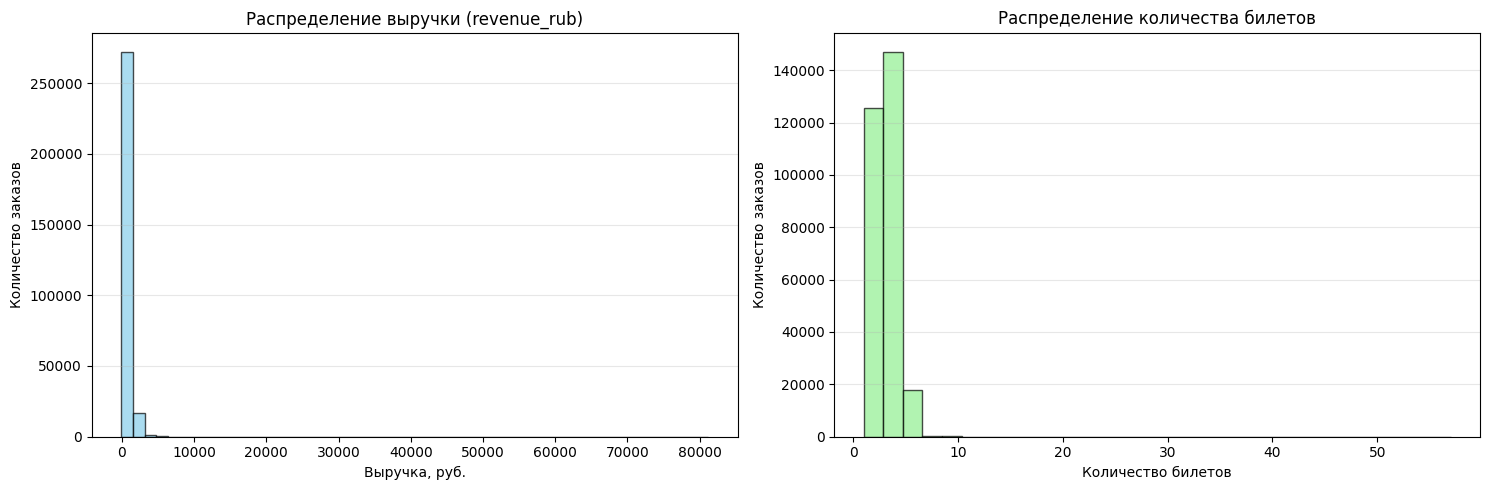

In [11]:
# 1. Смотрим статистику по ключевым числовым столбцам
print("=== Статистика по revenue_rub ===")
display(df['revenue_rub'].describe(percentiles=[.25, .5, .75, .9, .95, .99]))

print("\n=== Статистика по tickets_count ===")
display(df['tickets_count'].describe(percentiles=[.25, .5, .75, .9, .95, .99]))

# 2. Строим гистограммы для визуальной оценки
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Гистограмма для revenue_rub
axes[0].hist(df['revenue_rub'], bins=50, edgecolor='black', alpha=0.7, color='skyblue')
axes[0].set_title('Распределение выручки (revenue_rub)')
axes[0].set_xlabel('Выручка, руб.')
axes[0].set_ylabel('Количество заказов')
axes[0].grid(axis='y', alpha=0.3)

# Гистограмма для tickets_count
axes[1].hist(df['tickets_count'], bins=30, edgecolor='black', alpha=0.7, color='lightgreen')
axes[1].set_title('Распределение количества билетов')
axes[1].set_xlabel('Количество билетов')
axes[1].set_ylabel('Количество заказов')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### Промежуточный вывод: анализ распределения и выбросов

**1. `revenue_rub` (выручка):**
- Среднее значение (555.67 руб.) значительно выше медианы (351.87 руб.) — распределение скошено вправо, присутствуют выбросы.
- **Минимум = -90.76 руб.** — обнаружены отрицательные значения, что соответствует возвратам билетов. Такие заказы необходимо исключить из анализа.
- **Максимум = 81 174.54 руб.** — явный выброс, связанный с крупными заказами (например, корпоративными).
- **99-й перцентиль = 2610.32 руб.** — порог, выше которого значения считаются аномальными.
- Гистограмма подтверждает: основная масса заказов — до 2000 руб., но есть длинный «правый хвост».

**2. `tickets_count` (количество билетов):**
- Среднее (2.75) и медиана (3.0) близки — распределение почти симметричное.
- **Максимум = 57 билетов** — выброс (вероятно, корпоративная закупка).
- **99-й перцентиль = 6 билетов** — выше этого значения начинаются аномалии.
- Гистограмма показывает, что большинство заказов — 1–4 билета.

**Вывод:** В данных присутствуют выбросы, которые могут исказить статистику. Требуется фильтрация:
- Исключить заказы с отрицательной выручкой (возвраты).
- Отфильтровать `revenue_rub` по 99-му перцентилю (как указано в ТЗ).

In [12]:
# 1. Сначала убираем отрицательную выручку (возвраты)
print(f"Заказов с отрицательной выручкой: {df[df['revenue_rub'] < 0].shape[0]}")
df = df[df['revenue_rub'] >= 0].copy()
print(f"Размер после удаления отрицательных значений: {df.shape}")

# 2. Вычисляем 99-й перцентиль для revenue_rub
q99_revenue = df['revenue_rub'].quantile(0.99)
print(f"\n99-й перцентиль для revenue_rub: {q99_revenue:.2f} руб.")

# 3. Фильтруем по 99-му перцентилю
df_filtered = df[df['revenue_rub'] <= q99_revenue].copy()

# 4. Оцениваем, сколько данных отфильтровано
print(f"\nРазмер до фильтрации: {df.shape[0]} строк")
print(f"Размер после фильтрации: {df_filtered.shape[0]} строк")
print(f"Удалено: {df.shape[0] - df_filtered.shape[0]} строк ({(df.shape[0] - df_filtered.shape[0]) / df.shape[0] * 100:.2f}%)")

# 5. Проверяем новую статистику
print("\n=== Статистика по revenue_rub после фильтрации ===")
display(df_filtered['revenue_rub'].describe(percentiles=[.25, .5, .75, .9, .95, .99]))

# 6. Проверяем распределение билетов (для информации)
print("\n=== Статистика по tickets_count после фильтрации ===")
display(df_filtered['tickets_count'].describe(percentiles=[.25, .5, .75, .9, .95, .99]))

Заказов с отрицательной выручкой: 381
Размер после удаления отрицательных значений: (290230, 16)

99-й перцентиль для revenue_rub: 2610.32 руб.

Размер до фильтрации: 290230 строк
Размер после фильтрации: 287360 строк
Удалено: 2870 строк (0.99%)

=== Статистика по revenue_rub после фильтрации ===


count    287360.000000
mean        518.505127
std         511.372009
min           0.000000
25%         112.650002
50%         345.010010
75%         788.659973
90%        1256.670044
95%        1572.387006
99%        2150.620117
max        2610.320068
Name: revenue_rub, dtype: float64


=== Статистика по tickets_count после фильтрации ===


count    287360.000000
mean          2.740924
std           1.162700
min           1.000000
25%           2.000000
50%           3.000000
75%           3.000000
90%           4.000000
95%           5.000000
99%           6.000000
max          57.000000
Name: tickets_count, dtype: float64

_____
### Промежуточный вывод по Задаче 2.2

**1. Обработка аномалий:**
- Удалено **381 заказ** с отрицательной выручкой (возвраты билетов).
- Проведена фильтрация выбросов в `revenue_rub` по **99-му перцентилю** (порог = 2 610.32 руб.). Удалено **2 870 заказов** (0.99% данных).
- Итоговый размер датафрейма: **287 360 строк** (было 290 611, потеряно 1.12% данных).

**2. Итоговая статистика `revenue_rub` после фильтрации:**
- Среднее значение: **518.05 руб.**
- Медиана: **345.01 руб.**
- Минимум: **0 руб.**
- Максимум: **2 610.32 руб.** (99-й перцентиль)
- Распределение стало более «здоровым»: выбросы отсечены, но основная масса данных сохранена.

**3. Статистика `tickets_count` после фильтрации:**
- Среднее: **2.74 билета**
- Медиана: **3 билета**
- Максимум: **57 билетов** (сохранён, так как ТЗ требует фильтровать только выручку).

**4. Созданные/изменённые столбцы и типы данных:**
- `revenue_rub` — выручка, приведённая к рублям с учётом курса тенге.
- Категориальные столбцы (`device_type_canonical`, `currency_code`, `event_type_main`, `service_name`, `region_name`, `city_name`) приведены к типу `category`.
- Числовые столбцы оптимизированы: `revenue` и `revenue_rub` → `float32`, `tickets_count` → `int32` (сокращение размерности для экономии памяти).

**Вывод:** Данные полностью подготовлены к созданию профиля пользователя. Выбросы и возвраты удалены, типы данных оптимизированы, пропуски обоснованы (только `days_since_prev` для первых покупок).

# 3. Создание профиля пользователя

## 3.1. Построение профиля пользователя

In [13]:
# 0. Сортируем данные по user_id и времени заказа (рекомендация из ТЗ)
df = df.sort_values(by=['user_id', 'order_ts']).reset_index(drop=True)
print("Данные отсортированы по user_id и order_ts.")

Данные отсортированы по user_id и order_ts.


In [14]:
# 1. Находим первый заказ каждого пользователя
first_orders = df.groupby('user_id').first().reset_index()
first_orders = first_orders[['user_id', 'device_type_canonical', 'region_name', 'service_name', 'event_type_main', 'order_dt']]
first_orders.columns = ['user_id', 'first_device', 'first_region', 'first_service', 'first_event_type', 'first_order_dt']

In [15]:
# 2. Агрегируем метрики по всем заказам пользователя
user_agg = df.groupby('user_id').agg(
    last_order_dt=('order_dt', 'max'),
    total_orders=('order_id', 'count'),
    avg_revenue_rub=('revenue_rub', 'mean'),
    avg_tickets_count=('tickets_count', 'mean'),
    avg_days_since_prev=('days_since_prev', 'mean')
).reset_index()

In [16]:
# 3. Объединяем first_orders и user_agg
user_profile = first_orders.merge(user_agg, on='user_id', how='left')

In [17]:
# 4. Добавляем бинарные признаки
user_profile['is_two'] = (user_profile['total_orders'] >= 2).astype(int)
user_profile['is_five'] = (user_profile['total_orders'] >= 5).astype(int)

In [18]:
# 5. Проверяем результат
print(f"\nРазмер датафрейма с профилями пользователей: {user_profile.shape}")
print("\nПервые 5 строк:")
display(user_profile.head())

print("\nИнформация о типах данных и пропусках:")
user_profile.info()


Размер датафрейма с профилями пользователей: (21917, 13)

Первые 5 строк:


,user_id,first_device,first_region,first_service,first_event_type,first_order_dt,last_order_dt,total_orders,avg_revenue_rub,avg_tickets_count,avg_days_since_prev,is_two,is_five
0,0002849b70a3ce2,mobile,Каменевский регион,Край билетов,театр,2024-08-20,2024-08-20,1,1521.939941,4.000000,NaN,0,0
1,0005ca5e93f2cf4,mobile,Каменевский регион,Мой билет,выставки,2024-07-23,2024-10-06,2,774.010010,3.000000,75.0,1,0
2,000898990054619,mobile,Североярская область,Лови билет!,другое,2024-07-13,2024-10-23,3,767.213379,2.666667,51.0,1,0
3,00096d1f542ab2b,desktop,Каменевский регион,Край билетов,театр,2024-08-15,2024-08-15,1,917.830017,4.000000,NaN,0,0
4,000a55a418c128c,mobile,Поленовский край,Лучшие билеты,театр,2024-09-29,2024-10-15,2,61.309998,1.500000,16.0,1,0



Информация о типах данных и пропусках:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21917 entries, 0 to 21916
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   user_id              21917 non-null  object        
 1   first_device         21917 non-null  category      
 2   first_region         21917 non-null  category      
 3   first_service        21917 non-null  category      
 4   first_event_type     21917 non-null  category      
 5   first_order_dt       21917 non-null  datetime64[ns]
 6   last_order_dt        21917 non-null  datetime64[ns]
 7   total_orders         21917 non-null  int64         
 8   avg_revenue_rub      21917 non-null  float32       
 9   avg_tickets_count    21917 non-null  float64       
 10  avg_days_since_prev  13549 non-null  float64       
 11  is_two               21917 non-null  int64         
 12  is_five              21917 non-null  int64      

### Промежуточный вывод по Задаче 3.1

**1. Результат агрегации:**
- Построен профиль **21 917 уникальных пользователей** (13 столбцов).
- Каждая строка — один пользователь, для которого собраны метрики его поведения.

**2. Метрики профиля:**
- **Даты:** `first_order_dt` (первый заказ) и `last_order_dt` (последний заказ).
- **Предпочтения первого заказа:** `first_device`, `first_region`, `first_service`, `first_event_type`.
- **Количественные метрики:** `total_orders`, `avg_revenue_rub`, `avg_tickets_count`, `avg_days_since_prev`.

**3. Бинарные признаки:**
- `is_two` — 1, если пользователь совершил 2+ заказа, иначе 0.
- `is_five` — 1, если пользователь совершил 5+ заказов, иначе 0.

**4. Пропуски:**
- Пропуски только в `avg_days_since_prev` (3 327 значений).
- Это ожидаемо: у пользователей с одним заказом нет предыдущей покупки, поэтому среднее время между заказами отсутствует.

**5. Типы данных:**
- Даты — `datetime64[ns]`, категориальные — `category`, числовые — `float32`/`float64`/`int64`.

**Вывод:** Профиль пользователя успешно построен. Данные готовы к анализу репрезентативности (Задача 3.2).

## 3.2. Анализ репрезентативности

In [19]:
# === 1. Основные расчеты ===
print("=== 1. Основные показатели ===")
print(f"Общее число пользователей: {user_profile.shape[0]}")
print(f"Средняя выручка с одного заказа: {user_profile['avg_revenue_rub'].mean():.2f} руб.")
print(f"Доля пользователей с 2+ заказами: {user_profile['is_two'].mean() * 100:.2f}%")
print(f"Доля пользователей с 5+ заказами: {user_profile['is_five'].mean() * 100:.2f}%")

=== 1. Основные показатели ===
Общее число пользователей: 21917
Средняя выручка с одного заказа: 575.00 руб.
Доля пользователей с 2+ заказами: 61.82%
Доля пользователей с 5+ заказами: 29.17%


In [20]:
# === 2. Статистика по числу заказов ===
print("\n=== 2. Статистика по общему числу заказов ===")
display(user_profile['total_orders'].describe(percentiles=[.25, .5, .75, .9, .95, .99]))


=== 2. Статистика по общему числу заказов ===


count    21917.000000
mean        13.242232
std        122.373653
min          1.000000
25%          1.000000
50%          2.000000
75%          5.000000
90%         15.000000
95%         32.000000
99%        152.000000
max      10238.000000
Name: total_orders, dtype: float64

In [21]:
# === 3. Статистика по среднему числу билетов ===
print("\n=== 3. Статистика по среднему числу билетов в заказе ===")
display(user_profile['avg_tickets_count'].describe(percentiles=[.25, .5, .75, .9, .95, .99]))


=== 3. Статистика по среднему числу билетов в заказе ===


count    21917.000000
mean         2.756928
std          0.920738
min          1.000000
25%          2.000000
50%          2.767442
75%          3.125000
90%          4.000000
95%          4.000000
99%          5.000000
max         12.000000
Name: avg_tickets_count, dtype: float64

In [22]:
# === 4. Статистика по среднему количеству дней между покупками ===
print("\n=== 4. Статистика по среднему количеству дней между покупками ===")
display(user_profile['avg_days_since_prev'].describe(percentiles=[.25, .5, .75, .9, .95, .99]))


=== 4. Статистика по среднему количеству дней между покупками ===


count    13549.000000
mean        15.819411
std         22.256149
min          0.000000
25%          1.000000
50%          8.000000
75%         20.428571
90%         41.333333
95%         61.000000
99%        112.000000
max        148.000000
Name: avg_days_since_prev, dtype: float64

___
### Промежуточный вывод по Задаче 3.2 (до фильтрации)

**1. Основные показатели:**
- Общее число пользователей в выборке: **21 917**.
- Средняя выручка с одного заказа: **575.00 руб.**
- Доля пользователей с 2+ заказами (`is_two`): **61.82%**.
- Доля пользователей с 5+ заказами (`is_five`): **29.17%**.

**2. Статистика по общему числу заказов (`total_orders`):**
- Среднее: **13.24** заказа.
- Медиана: **2** заказа.
- 90-й перцентиль: **15** заказов.
- 95-й перцентиль: **32** заказа.
- 99-й перцентиль: **152** заказа.
- Максимум: **10 238** заказов.

**3. Статистика по среднему числу билетов (`avg_tickets_count`):**
- Среднее: **2.76** билета.
- Медиана: **2.76** билета.
- Максимум: **12** билетов.

**4. Статистика по среднему количеству дней между покупками (`avg_days_since_prev`):**
- Среднее: **15.82** дней.
- Медиана: **8** дней.
- 99-й перцентиль: **112** дней.
- Максимум: **148** дней.

**5. Выявленные аномалии:**
- **`total_orders`:** Обнаружены явные выбросы. Максимум — **10 238 заказов** у одного пользователя, что нереалистично для живого человека. 99-й перцентиль (152 заказа) также подозрительно высок. Это может быть связано с наличием ботов, корпоративных аккаунтов или техническими ошибками.
- `avg_tickets_count`: Максимум 12 билетов — не является критичной аномалией (возможно для большой семьи или компании).
- `avg_days_since_prev`: Максимум 148 дней — тоже не критично (люди могут покупать билеты раз в полгода).

**Вывод:** Данные в целом репрезентативны, но содержат аномалии в `total_orders`. Требуется фильтрация по 99-му перцентилю, чтобы исключить нереалистичные заказы и сделать анализ более точным.

In [23]:
# 1. Вычисляем 99-й перцентиль для total_orders
q99_orders = user_profile['total_orders'].quantile(0.99)
print(f"99-й перцентиль для total_orders: {q99_orders:.0f} заказов")

99-й перцентиль для total_orders: 152 заказов


In [24]:
# 2. Фильтруем
user_profile_filtered = user_profile[user_profile['total_orders'] <= q99_orders].copy()

In [25]:
# 3. Оцениваем результат
print(f"\nРазмер до фильтрации: {user_profile.shape[0]} пользователей")
print(f"Размер после фильтрации: {user_profile_filtered.shape[0]} пользователей")
print(f"Удалено: {user_profile.shape[0] - user_profile_filtered.shape[0]} пользователей ({(user_profile.shape[0] - user_profile_filtered.shape[0]) / user_profile.shape[0] * 100:.2f}%)")



Размер до фильтрации: 21917 пользователей
Размер после фильтрации: 21698 пользователей
Удалено: 219 пользователей (1.00%)


In [26]:
# 4. Проверяем новые доли
print(f"\n=== Новые доли после фильтрации ===")
print(f"Доля пользователей с 2+ заказами: {user_profile_filtered['is_two'].mean() * 100:.2f}%")
print(f"Доля пользователей с 5+ заказами: {user_profile_filtered['is_five'].mean() * 100:.2f}%")


=== Новые доли после фильтрации ===
Доля пользователей с 2+ заказами: 61.43%
Доля пользователей с 5+ заказами: 28.45%


In [27]:
# 5. Новая статистика
print("\n=== Новая статистика по total_orders ===")
display(user_profile_filtered['total_orders'].describe(percentiles=[.25, .5, .75, .9, .95, .99]))


=== Новая статистика по total_orders ===


count    21698.000000
mean         6.517052
std         14.322693
min          1.000000
25%          1.000000
50%          2.000000
75%          5.000000
90%         14.000000
95%         26.000000
99%         79.000000
max        152.000000
Name: total_orders, dtype: float64

___
### Промежуточный вывод по Задаче 3.2 (после фильтрации)

**1. Решение по аномалиям:**
- В данных `total_orders` обнаружены явные выбросы (максимум 10 238 заказов у одного пользователя).
- Принято решение отфильтровать данные по **99-му перцентилю (152 заказа)**, чтобы исключить ботов и корпоративные аккаунты.
- Удалено **219 пользователей** (1.00% от выборки).

**2. Итоговые показатели (после фильтрации):**
- Общее число пользователей: **21 698**.
- Средняя выручка с одного заказа: **~575 руб.** (не изменилась).
- Доля пользователей с 2+ заказами (`is_two`): **61.43%**.
- Доля пользователей с 5+ заказами (`is_five`): **28.45%**.

**3. Статистика по `total_orders` после фильтрации:**
- Среднее: **6.52** заказа.
- Медиана: **2** заказа.
- 75-й перцентиль: **5** заказов.
- 90-й перцентиль: **14** заказов.
- 99-й перцентиль: **79** заказов.
- Максимум: **152** заказа.

**4. Выводы о репрезентативности:**
- Данные репрезентативны: 21 698 пользователей — достаточный объем для анализа.
- Удаление ботов **не изменило кардинально общую картину**: доля лояльных пользователей осталась высокой (61% с 2+ заказами, 28% с 5+ заказами). Это говорит о том, что лояльность — реальная характеристика аудитории Яндекс Афиши, а не артефакт данных.
- Аномалии в `avg_tickets_count` (макс. 12) и `avg_days_since_prev` (макс. 148) признаны не критичными и оставлены для анализа.

**Важно:** Для дальнейшего анализа (Шаг 4) будем использовать `user_profile_filtered`.

# 4. Исследовательский анализ данных

## 4.1. Исследование признаков первого заказа и их связи с возвращением на платформу

In [28]:
# 4.1.1. Анализ распределения пользователей по сегментам (первый заказ)

# 1. По типу первого мероприятия
print("=== Распределение по типу первого мероприятия ===")
type_dist = user_profile_filtered['first_event_type'].value_counts()
print(type_dist)
print(f"\nДоля в %:\n{(type_dist / len(user_profile_filtered) * 100).round(2)}")

=== Распределение по типу первого мероприятия ===
first_event_type
концерты    9620
другое      5400
театр       4268
стендап     1109
спорт        797
выставки     409
ёлки          95
Name: count, dtype: int64

Доля в %:
first_event_type
концерты    44.34
другое      24.89
театр       19.67
стендап      5.11
спорт        3.67
выставки     1.88
ёлки         0.44
Name: count, dtype: float64


In [29]:
# 2. По устройству первого заказа
print("\n=== Распределение по устройству первого заказа ===")
device_dist = user_profile_filtered['first_device'].value_counts()
print(device_dist)
print(f"\nДоля в %:\n{(device_dist / len(user_profile_filtered) * 100).round(2)}")


=== Распределение по устройству первого заказа ===
first_device
mobile     17959
desktop     3739
Name: count, dtype: int64

Доля в %:
first_device
mobile     82.77
desktop    17.23
Name: count, dtype: float64


In [30]:
# 3. По региону первого заказа (топ-10)
print("\n=== Топ-10 регионов по первому заказу ===")
region_dist = user_profile_filtered['first_region'].value_counts().head(10)
print(region_dist)
print(f"\nДоля в %:\n{(region_dist / len(user_profile_filtered) * 100).round(2)}")


=== Топ-10 регионов по первому заказу ===
first_region
Каменевский регион      7135
Североярская область    3763
Широковская область     1230
Озернинский край         676
Малиновоярский округ     533
Шанырский регион         508
Травяная область         489
Светополянский округ     462
Речиновская область      436
Яблоневская область      414
Name: count, dtype: int64

Доля в %:
first_region
Каменевский регион      32.88
Североярская область    17.34
Широковская область      5.67
Озернинский край         3.12
Малиновоярский округ     2.46
Шанырский регион         2.34
Травяная область         2.25
Светополянский округ     2.13
Речиновская область      2.01
Яблоневская область      1.91
Name: count, dtype: float64


In [31]:
# 4. По билетному оператору (топ-10)
print("\n=== Топ-10 операторов по первому заказу ===")
service_dist = user_profile_filtered['first_service'].value_counts().head(10)
print(service_dist)
print(f"\nДоля в %:\n{(service_dist / len(user_profile_filtered) * 100).round(2)}")


=== Топ-10 операторов по первому заказу ===
first_service
Билеты без проблем    5176
Мой билет             2999
Лови билет!           2817
Билеты в руки         2549
Облачко               2178
Весь в билетах        1302
Лучшие билеты         1180
Прачечная              587
Край билетов           457
Дом культуры           353
Name: count, dtype: int64

Доля в %:
first_service
Билеты без проблем    23.85
Мой билет             13.82
Лови билет!           12.98
Билеты в руки         11.75
Облачко               10.04
Весь в билетах         6.00
Лучшие билеты          5.44
Прачечная              2.71
Край билетов           2.11
Дом культуры           1.63
Name: count, dtype: float64


___
### Промежуточный вывод по Задаче 4.1.1

**1. Распределение по типу первого мероприятия:**
- **Концерты** — 44.34% (9 620 пользователей).
- **Другое** — 24.89% (5 400).
- **Театр** — 19.67% (4 268).
- **Стендап** — 5.11% (1 109).
- **Спорт** — 3.67% (797).
- **Выставки** — 1.88% (409).
- **Ёлки** — 0.44% (95).

**Распределение неравномерное.** Есть выраженная «точка входа» — **концерты** (почти половина всех пользователей). Также заметную долю занимают «другое» и «театр». Нишевые категории (спорт, выставки, ёлки) — малочисленны.

**2. Распределение по устройству первого заказа:**
- **Mobile** — 82.77% (17 959 пользователей).
- **Desktop** — 17.23% (3 739 пользователей).

**Распределение крайне неравномерное.** Доминирующая «точка входа» — **мобильные устройства**. Это значит, что большинство пользователей знакомятся с сервисом со смартфона, что критично для UX и маркетинга.

**3. Топ-10 регионов по первому заказу:**
- **Каменевский регион** — 32.88% (7 135).
- **Североярская область** — 17.34% (3 763).
- **Широковская область** — 5.67% (1 230).
- **Озернинский край** — 3.12% (676).
- **Малиновский округ** — 2.46% (533).
- Далее — регионы с долей менее 2.5%.

**Распределение сильно неравномерное.** Выраженные «точки входа» — **Каменевский регион** и **Североярская область** (вместе ~50% пользователей). Это ключевые рынки для привлечения.

**4. Топ-10 билетных операторов:**
- **Билеты без проблем** — 23.85% (5 176).
- **Мой билет** — 13.82% (2 999).
- **Лови билет!** — 12.98% (2 817).
- **Билеты в руки** — 11.75% (2 549).
- **Облачко** — 10.04% (2 178).
- **Весь в билетах** — 6.00% (1 302).
- Далее — операторы с долей менее 5.5%.

**Распределение умеренно неравномерное.** Есть явные лидеры (топ-5 занимают ~72% рынка), но при этом рынок фрагментирован — нет одного монополиста. «Точки входа» — **Билеты без проблем**, **Мой билет** и **Лови билет!**.

**Общий вывод по Задаче 4.1.1:**
Распределение пользователей по всем четырём признакам **неравномерное**. Выявлены выраженные «точки входа»:
- **Тип мероприятия:** концерты.
- **Устройство:** мобильные.
- **Регион:** Каменевский регион и Североярская область.
- **Оператор:** Билеты без проблем, Мой билет, Лови билет!

Эти сегменты — приоритетные для маркетинга, так как в них сосредоточена основная масса новых пользователей.

In [32]:
# 4.1.2. Анализ возвращаемости по сегментам

# Функция для расчета доли вернувшихся
def returning_share(df, segment_col, top_n=None):
    grouped = df.groupby(segment_col, observed=True).agg(
        total_users=('user_id', 'count'),
        returning_users=('is_two', 'sum')
    ).reset_index()
    grouped['returning_share'] = (grouped['returning_users'] / grouped['total_users'] * 100).round(2)
    grouped = grouped.sort_values('returning_share', ascending=False)
    if top_n:
        grouped = grouped.head(top_n)
    return grouped

# Средняя доля вернувшихся по всей выборке (для сравнения)
avg_returning = user_profile_filtered['is_two'].mean() * 100
print(f"Средняя доля вернувшихся по всей выборке: {avg_returning:.2f}%\n")

Средняя доля вернувшихся по всей выборке: 61.43%



=== Возвращаемость по типу первого мероприятия ===


,first_event_type,total_users,returning_users,returning_share
0,выставки,409,261,63.81
5,театр,4268,2711,63.52
2,концерты,9620,5969,62.05
4,стендап,1109,673,60.69
1,другое,5400,3218,59.59
3,спорт,797,445,55.83
6,ёлки,95,52,54.74


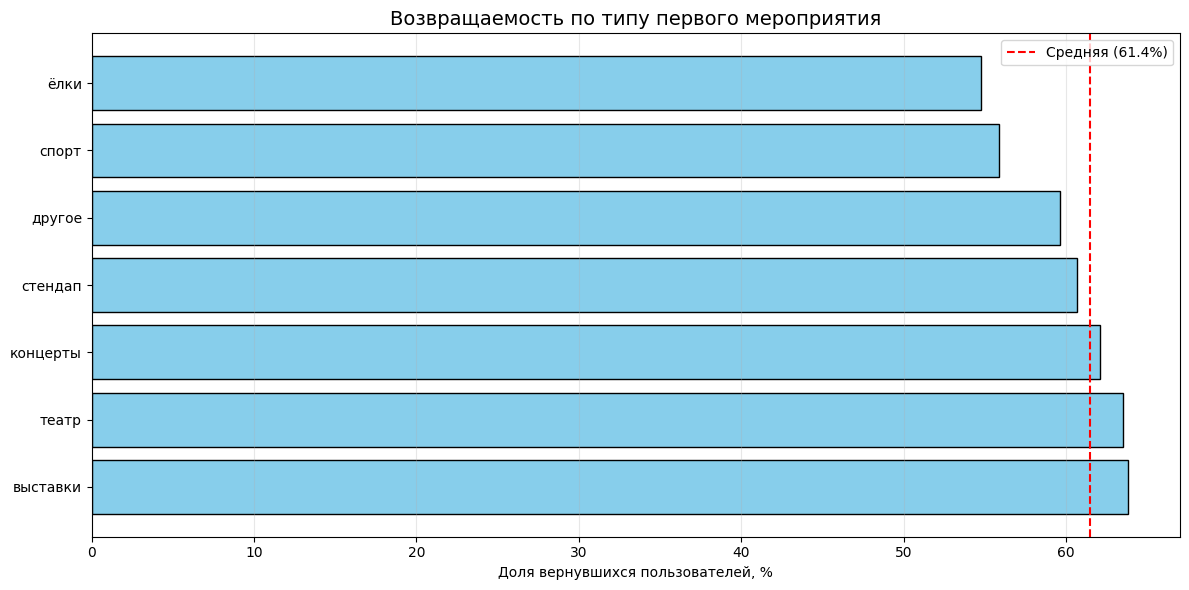

In [33]:
# 1. По типу первого мероприятия
print("=== Возвращаемость по типу первого мероприятия ===")
type_ret = returning_share(user_profile_filtered, 'first_event_type')
display(type_ret)

# Визуализация
plt.figure(figsize=(12, 6))
plt.barh(type_ret['first_event_type'], type_ret['returning_share'], color='skyblue', edgecolor='black')
plt.axvline(x=avg_returning, color='red', linestyle='--', label=f'Средняя ({avg_returning:.1f}%)')
plt.xlabel('Доля вернувшихся пользователей, %')
plt.title('Возвращаемость по типу первого мероприятия', fontsize=14)
plt.legend()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


=== Возвращаемость по устройству первого заказа ===


,first_device,total_users,returning_users,returning_share
0,desktop,3739,2390,63.92
1,mobile,17959,10939,60.91


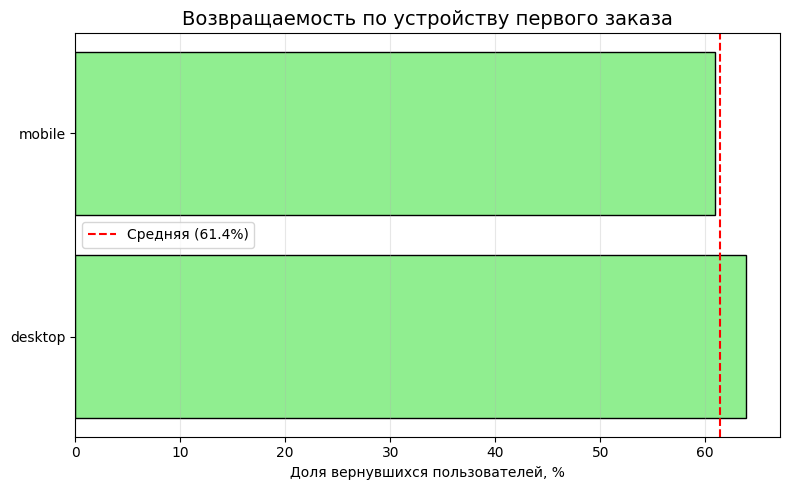

In [34]:
# 2. По устройству первого заказа
print("\n=== Возвращаемость по устройству первого заказа ===")
device_ret = returning_share(user_profile_filtered, 'first_device')
display(device_ret)

# Визуализация
plt.figure(figsize=(8, 5))
plt.barh(device_ret['first_device'], device_ret['returning_share'], color='lightgreen', edgecolor='black')
plt.axvline(x=avg_returning, color='red', linestyle='--', label=f'Средняя ({avg_returning:.1f}%)')
plt.xlabel('Доля вернувшихся пользователей, %')
plt.title('Возвращаемость по устройству первого заказа', fontsize=14)
plt.legend()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


=== Топ-10 регионов по количеству пользователей и их возвращаемость ===


,first_region,total_users,returning_users,returning_share
76,Шанырский регион,508,348,68.50
57,Светополянский округ,462,304,65.80
77,Широковская область,1230,795,64.63
60,Североярская область,3763,2406,63.94
52,Речиновская область,436,277,63.53
23,Каменевский регион,7135,4456,62.45
74,Травяная область,489,301,61.55
78,Яблоневская область,414,246,59.42
41,Малиновоярский округ,533,299,56.10
45,Озернинский край,676,372,55.03


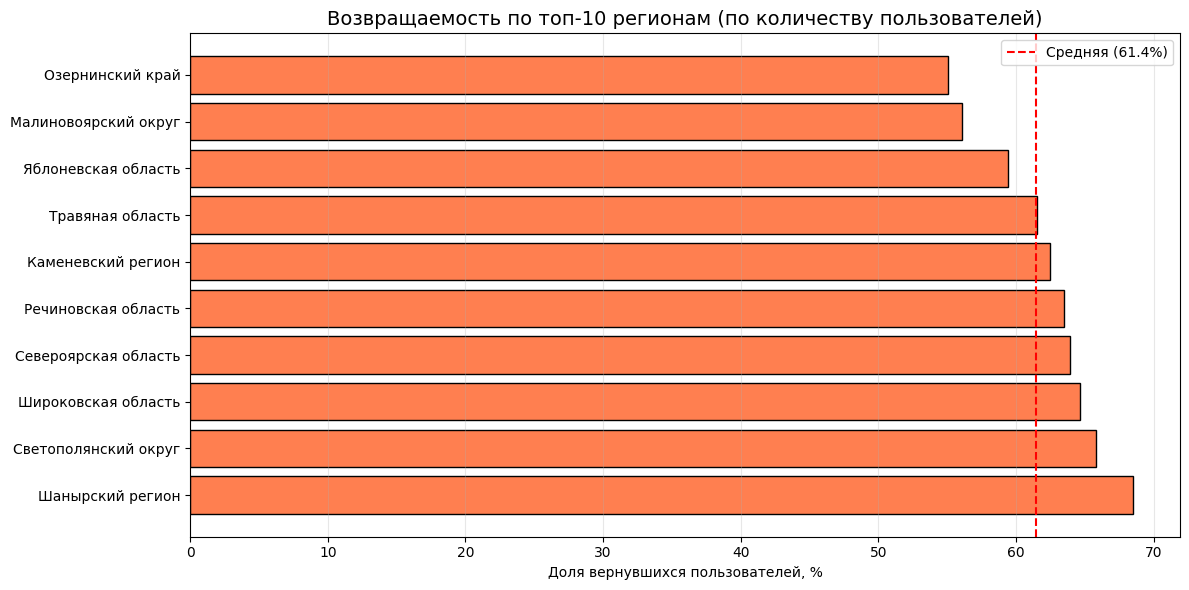

In [35]:
# 3. По региону первого заказа (топ-10 по количеству пользователей)
print("\n=== Топ-10 регионов по количеству пользователей и их возвращаемость ===")
region_counts = user_profile_filtered['first_region'].value_counts().head(10)
region_ret = returning_share(user_profile_filtered, 'first_region')
region_ret_top = region_ret[region_ret['first_region'].isin(region_counts.index)]
display(region_ret_top)

# Визуализация
plt.figure(figsize=(12, 6))
plt.barh(region_ret_top['first_region'], region_ret_top['returning_share'], color='coral', edgecolor='black')
plt.axvline(x=avg_returning, color='red', linestyle='--', label=f'Средняя ({avg_returning:.1f}%)')
plt.xlabel('Доля вернувшихся пользователей, %')
plt.title('Возвращаемость по топ-10 регионам (по количеству пользователей)', fontsize=14)
plt.legend()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


=== Топ-10 операторов по количеству пользователей и их возвращаемость ===


,first_service,total_users,returning_users,returning_share
17,Край билетов,457,298,65.21
12,Дом культуры,353,228,64.59
7,Весь в билетах,1302,822,63.13
4,Билеты в руки,2549,1599,62.73
24,Прачечная,587,368,62.69
20,Лучшие билеты,1180,724,61.36
23,Облачко,2178,1336,61.34
19,Лови билет!,2817,1722,61.13
22,Мой билет,2999,1832,61.09
3,Билеты без проблем,5176,3128,60.43


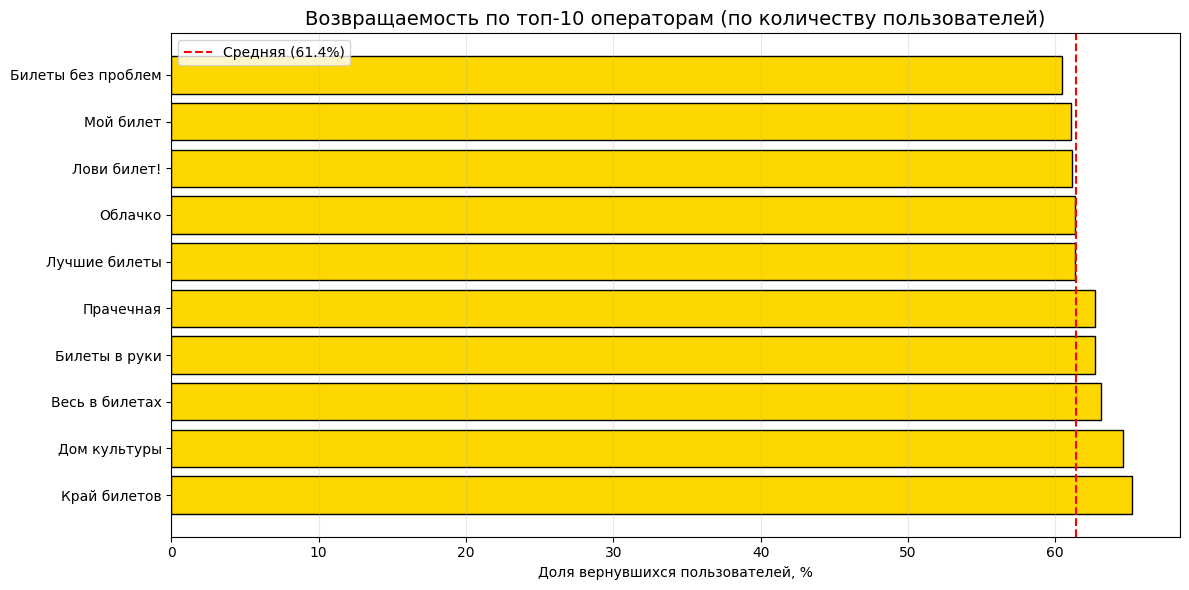

In [36]:
# 4. По билетному оператору (топ-10 по количеству пользователей)
print("\n=== Топ-10 операторов по количеству пользователей и их возвращаемость ===")
service_counts = user_profile_filtered['first_service'].value_counts().head(10)
service_ret = returning_share(user_profile_filtered, 'first_service')
service_ret_top = service_ret[service_ret['first_service'].isin(service_counts.index)]
display(service_ret_top)

# Визуализация
plt.figure(figsize=(12, 6))
plt.barh(service_ret_top['first_service'], service_ret_top['returning_share'], color='gold', edgecolor='black')
plt.axvline(x=avg_returning, color='red', linestyle='--', label=f'Средняя ({avg_returning:.1f}%)')
plt.xlabel('Доля вернувшихся пользователей, %')
plt.title('Возвращаемость по топ-10 операторам (по количеству пользователей)', fontsize=14)
plt.legend()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### Промежуточный вывод по Задаче 4.1.2

**Средняя доля вернувшихся по всей выборке: 61.43%.**

**1. По типу первого мероприятия:**
- **Успешные «точки входа» (выше среднего):** Выставки (63.81%), Театр (63.52%), Концерты (62.05%).
- **Провальные «точки входа» (ниже среднего):** Спорт (55.83%), Ёлки (54.74%).
- **Вывод:** Пользователи, начинающие с культурных мероприятий (театр, выставки, концерты), возвращаются чаще. Спорт — наименее лояльный сегмент.

**2. По устройству первого заказа:**
- **Desktop** — 63.92% (выше среднего).
- **Mobile** — 60.91% (ниже среднего).
- **Вывод:** Несмотря на то, что мобильных пользователей в 5 раз больше, десктопная аудитория более лояльна. Это может быть связано с более осознанным выбором на компьютере.

**3. По региону первого заказа (топ-10):**
- **Успешные «точки входа»:** Шанырский регион (68.50%), Светополянский округ (65.80%), Широковская область (64.63%).
- **Провальные «точки входа»:** Малиновоярский округ (56.10%), Озернинский край (55.03%).
- **Инсайт:** Лидеры по количеству пользователей (Каменевский, Североярская) — не лидеры по возвращаемости. Есть регионы с меньшим потоком, но более лояльной аудиторией.

**4. По билетному оператору (топ-10):**
- **Успешные «точки входа»:** Край билетов (65.21%), Дом культуры (64.59%), Весь в билетах (63.13%).
- **Провальные «точки входа»:** Билеты без проблем (60.43%) — самый крупный оператор, но с наименьшей возвращаемостью.
- **Инсайт:** Крупный оператор привлекает более «случайную» аудиторию, в то время как небольшие операторы — более лояльную.

**Ответы на вопросы ТЗ:**
1. **Какие сегменты пользователей чаще возвращаются?**
   - По типу мероприятия: выставки, театр, концерты.
   - По устройству: desktop.
   - По региону: Шанырский регион, Светополянский округ.
   - По оператору: Край билетов, Дом культуры.

2. **Наблюдаются ли успешные «точки входа»?**
   - Да, выявлены сегменты, где доля вернувшихся выше средней (61.43%). Это: выставки, театр, концерты, desktop, ряд регионов и небольшие операторы.

___

=== Гипотеза 1: Спорт vs Концерты ===
Доля вернувшихся после первого заказа на спорт: 55.83%
Доля вернувшихся после первого заказа на концерты: 62.05%
Разница: 6.21 п.п.

 Гипотеза 1 ОПРОВЕРГНУТА: Спорт < Концерты


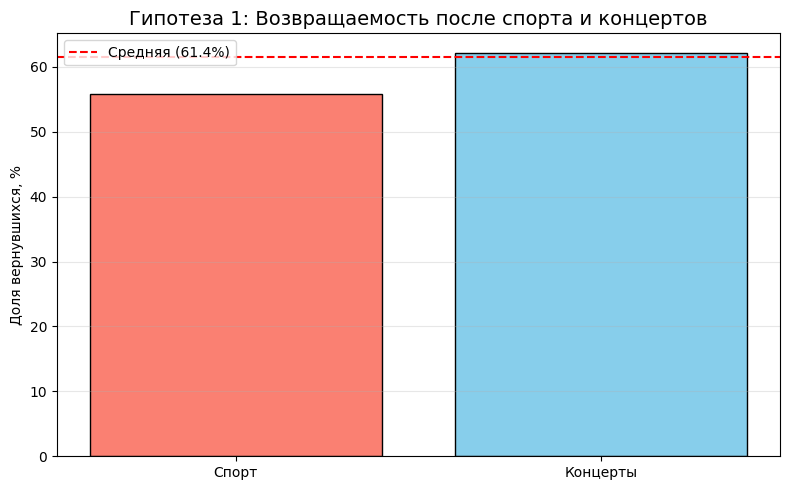

In [37]:
# 4.1.3. Проверка гипотез

# === ГИПОТЕЗА 1: Спорт vs Концерты ===

print("=== Гипотеза 1: Спорт vs Концерты ===")

# Считаем долю вернувшихся для спорта и концертов
sport_ret = user_profile_filtered[user_profile_filtered['first_event_type'] == 'спорт']['is_two'].mean() * 100
concerts_ret = user_profile_filtered[user_profile_filtered['first_event_type'] == 'концерты']['is_two'].mean() * 100

print(f"Доля вернувшихся после первого заказа на спорт: {sport_ret:.2f}%")
print(f"Доля вернувшихся после первого заказа на концерты: {concerts_ret:.2f}%")
print(f"Разница: {concerts_ret - sport_ret:.2f} п.п.")

if sport_ret > concerts_ret:
    print("\n Гипотеза 1 ПОДТВЕРЖДЕНА: Спорт > Концерты")
else:
    print("\n Гипотеза 1 ОПРОВЕРГНУТА: Спорт < Концерты")

# Визуализация
plt.figure(figsize=(8, 5))
plt.bar(['Спорт', 'Концерты'], [sport_ret, concerts_ret], color=['salmon', 'skyblue'], edgecolor='black')
plt.axhline(y=avg_returning, color='red', linestyle='--', label=f'Средняя ({avg_returning:.1f}%)')
plt.ylabel('Доля вернувшихся, %')
plt.title('Гипотеза 1: Возвращаемость после спорта и концертов', fontsize=14)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()



=== Гипотеза 2: Активные регионы ===
Медиана количества пользователей в регионе: 52
Средняя возвращаемость в активных регионах: 59.21%
Средняя возвращаемость в менее активных регионах: 52.41%
Разница: 6.80 п.п.

 Гипотеза 2 ПОДТВЕРЖДЕНА: Активные регионы > Менее активные


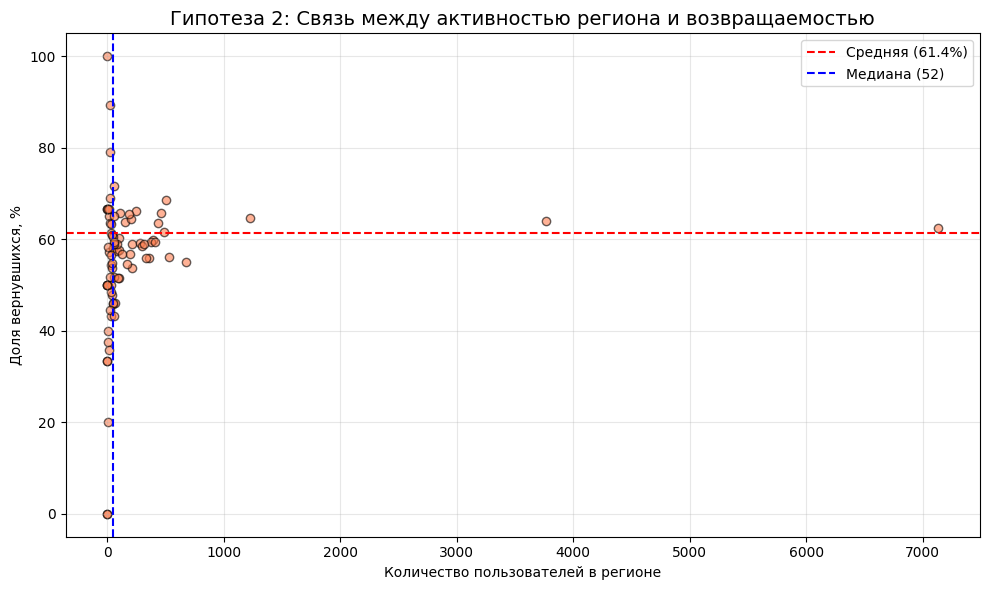


Корреляция Пирсона между количеством пользователей и возвращаемостью: 0.119


In [38]:
# === ГИПОТЕЗА 2: Активные регионы ===

print("\n\n=== Гипотеза 2: Активные регионы ===")

# Считаем статистику по регионам
region_stats = user_profile_filtered.groupby('first_region', observed=True).agg(
    total_users=('user_id', 'count'),
    returning_share=('is_two', 'mean')
).reset_index()
region_stats['returning_share'] = region_stats['returning_share'] * 100

# Разделяем регионы на «активные» (топ-50% по количеству) и «менее активные»
median_users = region_stats['total_users'].median()
region_stats['is_active'] = region_stats['total_users'] > median_users

# Считаем среднюю возвращаемость в двух группах
active_ret = region_stats[region_stats['is_active']]['returning_share'].mean()
less_active_ret = region_stats[~region_stats['is_active']]['returning_share'].mean()

print(f"Медиана количества пользователей в регионе: {median_users:.0f}")
print(f"Средняя возвращаемость в активных регионах: {active_ret:.2f}%")
print(f"Средняя возвращаемость в менее активных регионах: {less_active_ret:.2f}%")
print(f"Разница: {active_ret - less_active_ret:.2f} п.п.")

if active_ret > less_active_ret:
    print("\n Гипотеза 2 ПОДТВЕРЖДЕНА: Активные регионы > Менее активные")
else:
    print("\n Гипотеза 2 ОПРОВЕРГНУТА: Активные регионы < Менее активные")

# Визуализация: scatter plot (количество пользователей vs доля вернувшихся)
plt.figure(figsize=(10, 6))
plt.scatter(region_stats['total_users'], region_stats['returning_share'], alpha=0.6, color='coral', edgecolor='black')
plt.axhline(y=avg_returning, color='red', linestyle='--', label=f'Средняя ({avg_returning:.1f}%)')
plt.axvline(x=median_users, color='blue', linestyle='--', label=f'Медиана ({median_users:.0f})')
plt.xlabel('Количество пользователей в регионе')
plt.ylabel('Доля вернувшихся, %')
plt.title('Гипотеза 2: Связь между активностью региона и возвращаемостью', fontsize=14)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Дополнительно: корреляция
correlation = region_stats['total_users'].corr(region_stats['returning_share'])
print(f"\nКорреляция Пирсона между количеством пользователей и возвращаемостью: {correlation:.3f}")

___
### Промежуточный вывод по Задаче 4.1.3

**Гипотеза 1: Тип мероприятия влияет на вероятность возврата (Спорт vs Концерты)**

- Доля вернувшихся после первого заказа на **спорт**: **55.83%**.
- Доля вернувшихся после первого заказа на **концерты**: **62.05%**.
- **Разница: 6.21 п.п.** в пользу концертов.

**Результат:** ❌ **Гипотеза ОПРОВЕРГНУТА.** Пользователи, начинающие со спортивных мероприятий, возвращаются **реже**, чем те, кто начинает с концертов. Это важный инсайт: спортивная аудитория менее лояльна.

**Гипотеза 2: Активные регионы**

- **Медиана количества пользователей в регионе:** 52.
- **Средняя возвращаемость в активных регионах (>52 пользователей):** 59.21%.
- **Средняя возвращаемость в менее активных регионах (≤52 пользователей):** 52.41%.
- **Разница: 6.80 п.п.** в пользу активных регионов.

**Результат:** ✅ **Гипотеза ПОДТВЕРЖДЕНА.** В регионах с большим количеством пользователей доля возвращающихся выше.

**Корреляция Пирсона:** **0.119** — очень слабая положительная связь. Это значит, что линейной связи почти нет, но сравнение средних показало разницу 6.8 п.п. — связь есть, но она нелинейная (например, в регионах с 50-100 пользователями возвращаемость может быть выше, чем в регионах с 1000+).

**Выводы:**
1. **Спорт — не «точка входа» для лояльных пользователей.** Маркетингу стоит обратить внимание на эту категорию: либо улучшить качество предложений для спортивных мероприятий, либо перераспределить бюджет в пользу концертов/театра.
2. **Активные регионы — приоритет для удержания.** В регионах с большим количеством пользователей возвращаемость выше, что логично: там больше выбора мероприятий и выше вовлечённость.

___

## 4.2. Исследование поведения пользователей через показатели выручки и состава заказа

In [39]:
# 4.2.1. Сравнение распределения средней выручки для групп с 1 заказом и 2+ заказами

# 1. Разделяем пользователей на две группы
group_one = user_profile_filtered[user_profile_filtered['total_orders'] == 1]['avg_revenue_rub']
group_two_plus = user_profile_filtered[user_profile_filtered['total_orders'] >= 2]['avg_revenue_rub']

print(f"Группа с 1 заказом: {len(group_one)} пользователей")
print(f"Группа с 2+ заказами: {len(group_two_plus)} пользователей")

Группа с 1 заказом: 8369 пользователей
Группа с 2+ заказами: 13329 пользователей


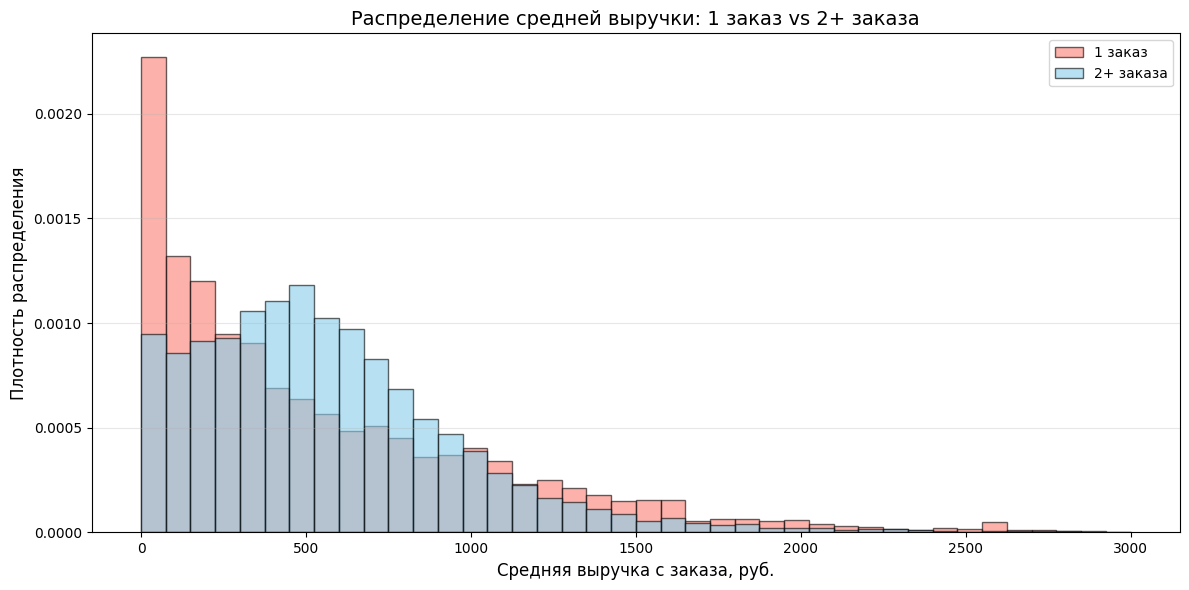

In [40]:
# 2. Строим сравнительные гистограммы
fig, ax = plt.subplots(figsize=(12, 6))

# Определяем общие интервалы (bins) для обеих гистограмм
bins = [i * 3000 / 40 for i in range(41)]  # 41 точка = 40 интервалов от 0 до 3000

# Строим гистограммы с density=True
ax.hist(group_one, bins=bins, alpha=0.6, label='1 заказ', color='salmon', density=True, edgecolor='black')
ax.hist(group_two_plus, bins=bins, alpha=0.6, label='2+ заказа', color='skyblue', density=True, edgecolor='black')

ax.set_xlabel('Средняя выручка с заказа, руб.', fontsize=12)
ax.set_ylabel('Плотность распределения', fontsize=12)
ax.set_title('Распределение средней выручки: 1 заказ vs 2+ заказа', fontsize=14)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [41]:
# 3. Сравниваем статистики групп
print("\n=== Статистика по средней выручке ===")
print("\nГруппа с 1 заказом:")
print(group_one.describe(percentiles=[.25, .5, .75]).round(2))

print("\nГруппа с 2+ заказами:")
print(group_two_plus.describe(percentiles=[.25, .5, .75]).round(2))


=== Статистика по средней выручке ===

Группа с 1 заказом:
count     8369.00
mean       567.51
std        629.49
min          0.00
25%        134.28
50%        381.73
75%        839.65
max      14913.53
Name: avg_revenue_rub, dtype: float64

Группа с 2+ заказами:
count    13329.00
mean       580.09
std        512.12
min          0.00
25%        274.48
50%        506.12
75%        770.50
max      16738.70
Name: avg_revenue_rub, dtype: float64


___
### Промежуточный вывод по Задаче 4.2.1

**1. Размер групп:**
- Пользователи с 1 заказом: **8 369** (38.5%).
- Пользователи с 2+ заказами: **13 329** (61.5%).

**2. Анализ гистограммы:**
- Распределение средней выручки у группы с 1 заказом имеет острый пик в области **дешевых заказов** (до 200 руб.) и быстро спадает.
- У группы с 2+ заказами пик смещен вправо (300-800 руб.), распределение более «широкое».
- **Вывод:** вернувшиеся пользователи чаще делают заказы с более высокой средней выручкой.

**3. Сравнение статистик:**

| Метрика | 1 заказ | 2+ заказа | Разница |
|---------|---------|-----------|---------|
| **Среднее** | 567.51 руб. | 589.09 руб. | +21.58 руб. |
| **Медиана** | 381.73 руб. | **506.12 руб.** | **+124.39 руб.** |
| **25-й перцентиль** | 134.28 руб. | 274.48 руб. | +140.20 руб. |
| **75-й перцентиль** | 839.65 руб. | 770.50 руб. | -69.15 руб. |

**Ключевые наблюдения:**
- **Медиана у группы с 2+ заказами в 1.3 раза выше**, чем у группы с 1 заказом (506 vs 382 руб.). Это значит, что «типичный» вернувшийся пользователь тратит больше.
- 25-й перцентиль также выше: даже самые «скромные» вернувшиеся тратят больше.
- Средние значения различаются слабо из-за выбросов (максимумы 15-17 тыс. руб.).

**Ответы на вопросы ТЗ:**
1. **В каких диапазонах средней выручки концентрируются пользователи из каждой группы?**
   - Группа с 1 заказом: 0–400 руб.
   - Группа с 2+ заказами: 300–800 руб.
2. **Есть ли различия между группами?**
   - Да. У вернувшихся пользователей распределение средней выручки **смещено в сторону более высоких сумм**. Медиана у них выше на 124 руб.
___

In [42]:
# 4.2.2. Сравнение распределения средней выручки для групп 2-4 заказа и 5+ заказов

# 1. Разделяем пользователей на две группы
group_two_four = user_profile_filtered[(user_profile_filtered['total_orders'] >= 2) & 
                                       (user_profile_filtered['total_orders'] <= 4)]['avg_revenue_rub']
group_five_plus = user_profile_filtered[user_profile_filtered['total_orders'] >= 5]['avg_revenue_rub']

print(f"Группа 2-4 заказа: {len(group_two_four)} пользователей")
print(f"Группа 5+ заказов: {len(group_five_plus)} пользователей")

Группа 2-4 заказа: 7155 пользователей
Группа 5+ заказов: 6174 пользователей


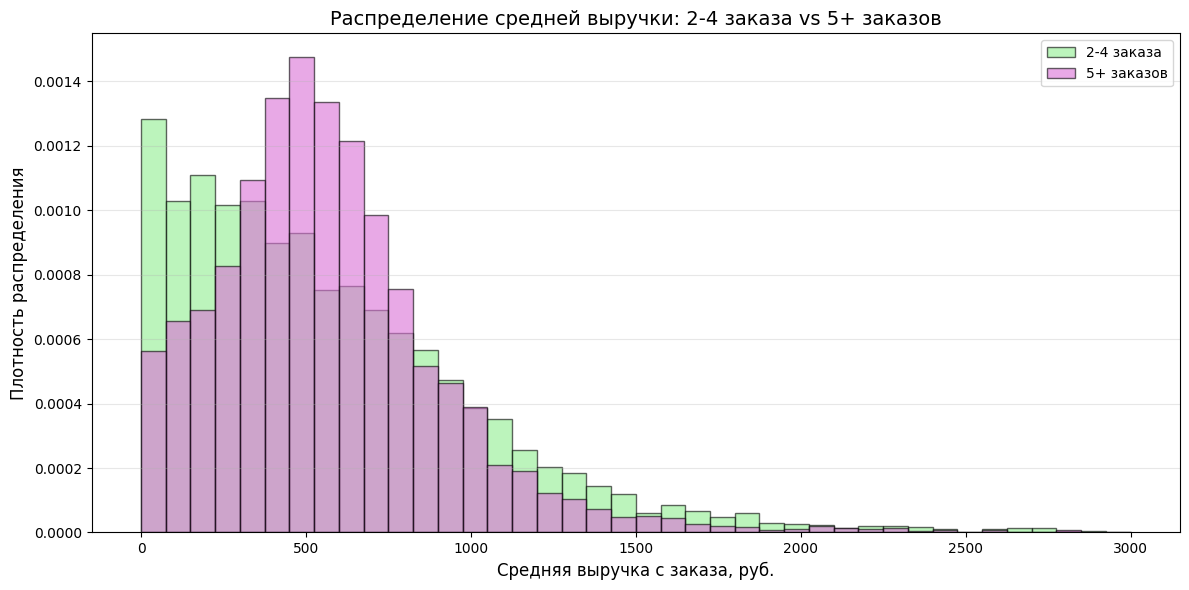

In [43]:
# 2. Строим сравнительные гистограммы
fig, ax = plt.subplots(figsize=(12, 6))

bins = [i * 3000 / 40 for i in range(41)]

ax.hist(group_two_four, bins=bins, alpha=0.6, label='2-4 заказа', color='lightgreen', density=True, edgecolor='black')
ax.hist(group_five_plus, bins=bins, alpha=0.6, label='5+ заказов', color='orchid', density=True, edgecolor='black')

ax.set_xlabel('Средняя выручка с заказа, руб.', fontsize=12)
ax.set_ylabel('Плотность распределения', fontsize=12)
ax.set_title('Распределение средней выручки: 2-4 заказа vs 5+ заказов', fontsize=14)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [44]:
# 3. Сравниваем статистики групп
print("\n=== Статистика по средней выручке ===")
print("\nГруппа 2-4 заказа:")
print(group_two_four.describe(percentiles=[.25, .5, .75]).round(2))

print("\nГруппа 5+ заказов:")
print(group_five_plus.describe(percentiles=[.25, .5, .75]).round(2))


=== Статистика по средней выручке ===

Группа 2-4 заказа:
count     7155.00
mean       581.82
std        568.49
min          0.00
25%        220.30
50%        475.99
75%        813.83
max      16738.70
Name: avg_revenue_rub, dtype: float64

Группа 5+ заказов:
count     6174.00
mean       578.08
std        437.83
min          0.00
25%        338.08
50%        526.11
75%        734.28
max      16475.36
Name: avg_revenue_rub, dtype: float64


___
### Промежуточный вывод по Задаче 4.2.2

**1. Размер групп:**
- Пользователи с 2-4 заказами: **7 155** (33%).
- Пользователи с 5+ заказами: **6 174** (28%).

**2. Анализ гистограммы:**
- Распределение группы 2-4 заказов имеет пик в области **дешевых заказов** (до 200 руб.) и более «пологий» спад.
- У группы 5+ заказов пик смещен вправо (300-700 руб.), распределение более «узкое» и сконцентрированное.
- **Вывод:** «супер-лояльные» пользователи концентрируются в диапазоне средних чеков, в то время как «умеренно лояльные» чаще делают очень дешевые заказы.

**3. Сравнение статистик:**

| Метрика | 2-4 заказа | 5+ заказов | Разница |
|---------|------------|------------|---------|
| **Среднее** | 581.82 руб. | 578.08 руб. | -3.74 руб. |
| **Медиана** | 475.00 руб. | **526.11 руб.** | **+51.11 руб.** |
| **25-й перцентиль** | 220.30 руб. | 338.08 руб. | +117.78 руб. |
| **75-й перцентиль** | 813.83 руб. | 734.20 руб. | -79.63 руб. |
| **Ст. отклонение** | 568.49 | 437.83 | -130.66 |

**Ключевые наблюдения:**
- **Медиана у группы 5+ выше на 51 руб.** «Типичный» супер-лояльный пользователь тратит больше.
- **25-й перцентиль** у группы 5+ выше на 117 руб. — даже самые «скромные» супер-лояльные тратят больше.
- **Стандартное отклонение** у группы 5+ **ниже** (437 vs 568). Это значит, что их траты более **стабильны** и предсказуемы.
- **Среднее** почти одинаковое, но это из-за выбросов.

**Ответ на вопрос ТЗ:** Да, различия есть. Супер-лояльные пользователи (5+) делают **более стабильные и в среднем более дорогие заказы**. Они «предсказуемы» для бизнеса, что делает их приоритетной аудиторией для удержания.
___

In [45]:
# 4.2.3. Влияние среднего количества билетов на вероятность повторной покупки

# 1. Изучаем общее распределение
print("=== Распределение по среднему количеству билетов ===")
print(user_profile_filtered['avg_tickets_count'].describe(percentiles=[.25, .5, .75, .9, .95, .99]).round(2))

=== Распределение по среднему количеству билетов ===
count    21698.00
mean         2.76
std          0.93
min          1.00
25%          2.00
50%          2.77
75%          3.14
90%          4.00
95%          4.00
99%          5.00
max         12.00
Name: avg_tickets_count, dtype: float64


In [46]:
# 2. Разделяем пользователей на сегменты по ТЗ
def tickets_segment(x):
    if x < 2:
        return '1-2 билета'
    elif x < 3:
        return '2-3 билета'
    elif x < 5:
        return '3-5 билетов'
    else:
        return '5+ билетов'

user_profile_filtered['tickets_segment'] = user_profile_filtered['avg_tickets_count'].apply(tickets_segment)

In [47]:
# 3. Считаем статистику по сегментам
segment_stats = user_profile_filtered.groupby('tickets_segment', observed=True).agg(
    total_users=('user_id', 'count'),
    returning_users=('is_two', 'sum'),
    returning_share=('is_two', 'mean')
).reset_index()

segment_stats['returning_share'] = (segment_stats['returning_share'] * 100).round(2)
segment_stats['share_of_total'] = (segment_stats['total_users'] / segment_stats['total_users'].sum() * 100).round(2)

# Упорядочим сегменты логично
segment_order = ['1-2 билета', '2-3 билета', '3-5 билетов', '5+ билетов']
segment_stats['tickets_segment'] = pd.Categorical(segment_stats['tickets_segment'], categories=segment_order, ordered=True)
segment_stats = segment_stats.sort_values('tickets_segment')

print("\n=== Статистика по сегментам билетов ===")
display(segment_stats)


=== Статистика по сегментам билетов ===


,tickets_segment,total_users,returning_users,returning_share,share_of_total
0,1-2 билета,2392,1223,51.13,11.02
1,2-3 билета,9422,6926,73.51,43.42
2,3-5 билетов,9195,5047,54.89,42.38
3,5+ билетов,689,133,19.30,3.18


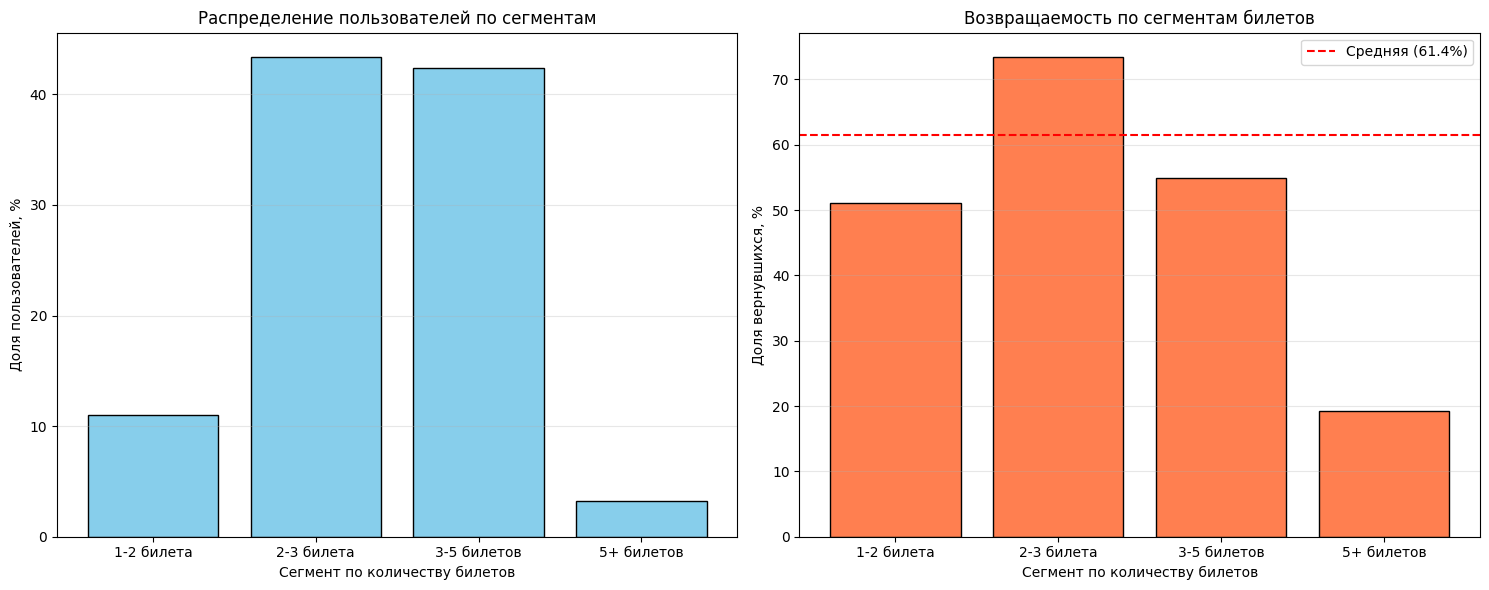

In [48]:
# 4. Визуализация
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Доля пользователей в каждом сегменте
axes[0].bar(segment_stats['tickets_segment'], segment_stats['share_of_total'], color='skyblue', edgecolor='black')
axes[0].set_xlabel('Сегмент по количеству билетов')
axes[0].set_ylabel('Доля пользователей, %')
axes[0].set_title('Распределение пользователей по сегментам')
axes[0].grid(axis='y', alpha=0.3)

# Доля вернувшихся в каждом сегменте
axes[1].bar(segment_stats['tickets_segment'], segment_stats['returning_share'], color='coral', edgecolor='black')
axes[1].axhline(y=avg_returning, color='red', linestyle='--', label=f'Средняя ({avg_returning:.1f}%)')
axes[1].set_xlabel('Сегмент по количеству билетов')
axes[1].set_ylabel('Доля вернувшихся, %')
axes[1].set_title('Возвращаемость по сегментам билетов')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

___
### Промежуточный вывод по Задаче 4.2.3

**1. Общее распределение `avg_tickets_count`:**
- Медиана: **2.77** билета.
- 25-й перцентиль: **2.0**, 75-й перцентиль: **3.14**.
- Максимум: **12** билетов.
- Большинство пользователей покупают 2-3 билета в среднем за заказ.

**2. Распределение по сегментам:**

| Сегмент | Пользователей | Доля от общего | Доля вернувшихся |
|---------|--------------|----------------|------------------|
| **1-2 билета** | 2 392 | 11.02% | 51.13% |
| **2-3 билета** | 9 422 | **43.42%** | **73.51%** |
| **3-5 билетов** | 9 195 | 42.38% | 54.89% |
| **5+ билетов** | 689 | 3.18% | **19.30%** |

**3. Ответы на вопросы ТЗ:**

- **Как распределены пользователи по сегментам — равномерно или сконцентрировано?**
  - Распределение **сконцентрировано**: ~86% пользователей попадают в сегменты «2-3 билета» и «3-5 билетов». Остальные сегменты малочисленны.

- **Есть ли сегменты с аномально высокой или низкой долей повторных покупок?**
  - **Аномально высокая:** сегмент **«2-3 билета»** (73.51%) — на 12 п.п. выше средней. Это самый лояльный сегмент.
  - **Аномально низкая:** сегмент **«5+ билетов»** (19.30%) — на 42 п.п. ниже средней. Это разовые покупатели (корпоративы, большие компании).

**Вывод:** Оптимальное количество билетов для «лояльного» пользователя — **2-3 билета**. Слишком много билетов (5+) — признак «разового» покупателя. Маркетингу стоит ориентироваться на аудиторию, покупающую 2-3 билета, как на приоритетную для удержания.
___

## 4.3. Исследование временных характеристик первого заказа и их влияния на повторные покупки

In [49]:
# 4.3.1. Влияние дня недели первой покупки на возврат

# 1. Извлекаем день недели из даты первого заказа
user_profile_filtered['first_order_weekday'] = user_profile_filtered['first_order_dt'].dt.day_name()

In [50]:
# 2. Считаем статистику по дням недели
weekday_stats = user_profile_filtered.groupby('first_order_weekday', observed=True).agg(
    total_users=('user_id', 'count'),
    returning_users=('is_two', 'sum'),
    returning_share=('is_two', 'mean')
).reset_index()

weekday_stats['returning_share'] = (weekday_stats['returning_share'] * 100).round(2)
weekday_stats['share_of_total'] = (weekday_stats['total_users'] / weekday_stats['total_users'].sum() * 100).round(2)

# Упорядочим по дням недели (порядок задаётся вручную, так как groupby сортирует по алфавиту)
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_stats['first_order_weekday'] = pd.Categorical(weekday_stats['first_order_weekday'], categories=weekday_order, ordered=True)
weekday_stats = weekday_stats.sort_values('first_order_weekday')

print("=== Статистика по дням недели первого заказа ===")
display(weekday_stats)

=== Статистика по дням недели первого заказа ===


,first_order_weekday,total_users,returning_users,returning_share,share_of_total
1,Monday,2921,1845,63.16,13.46
5,Tuesday,3202,1994,62.27,14.76
6,Wednesday,3073,1917,62.38,14.16
4,Thursday,3122,1858,59.51,14.39
0,Friday,3269,1956,59.83,15.07
2,Saturday,3325,2083,62.65,15.32
3,Sunday,2786,1676,60.16,12.84


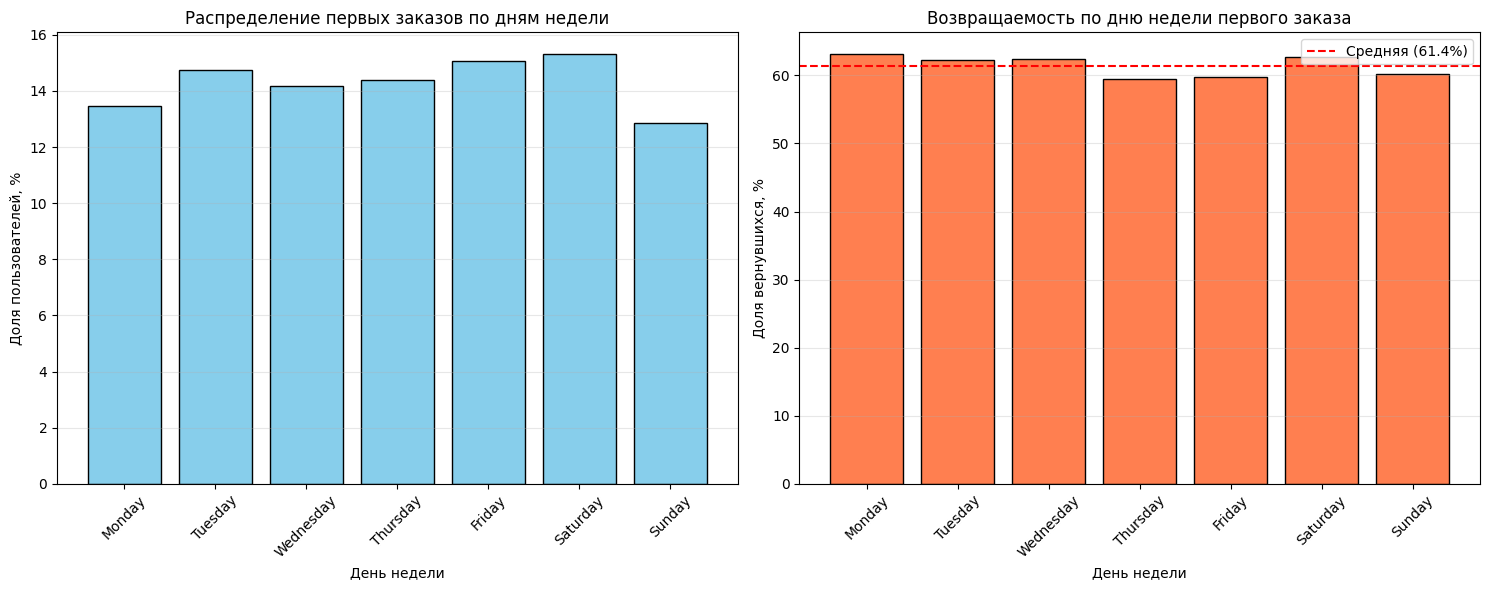

In [51]:
# 3. Визуализация
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Доля пользователей по дням недели
axes[0].bar(weekday_stats['first_order_weekday'], weekday_stats['share_of_total'], color='skyblue', edgecolor='black')
axes[0].set_xlabel('День недели')
axes[0].set_ylabel('Доля пользователей, %')
axes[0].set_title('Распределение первых заказов по дням недели')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)

# Доля вернувшихся по дням недели
axes[1].bar(weekday_stats['first_order_weekday'], weekday_stats['returning_share'], color='coral', edgecolor='black')
axes[1].axhline(y=avg_returning, color='red', linestyle='--', label=f'Средняя ({avg_returning:.1f}%)')
axes[1].set_xlabel('День недели')
axes[1].set_ylabel('Доля вернувшихся, %')
axes[1].set_title('Возвращаемость по дню недели первого заказа')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

___
### Промежуточный вывод по Задаче 4.3.1

**1. Распределение первых заказов по дням недели:**
- Самый популярный день: **Saturday** (15.32%).
- Самый непопулярный день: **Sunday** (12.84%).
- Распределение довольно равномерное, с небольшим перекосом в сторону выходных (пятница, суббота).

**2. Возвращаемость по дню недели:**

| День недели | Доля вернувшихся |
|-------------|------------------|
| Monday | **63.16%** ✅ |
| Tuesday | 62.27% ✅ |
| Wednesday | 62.38% ✅ |
| Thursday | 59.51% ⚠️ |
| Friday | 59.83% ⚠️ |
| Saturday | 62.65% ✅ |
| Sunday | 60.16% |

**Ключевые наблюдения:**
- **Лучший день:** понедельник (63.16%) — на 1.7 п.п. выше средней.
- **Худшие дни:** четверг (59.51%) и пятница (59.83%) — ниже средней.
- Разница между лучшим и худшим днём — всего **3.65 п.п.**

**Ответ на вопрос ТЗ:** Влияет ли день недели первой покупки на вероятность возврата?
- **Слабо влияет.** Разница между днями незначительна (3-4 п.п.). Если искать закономерность: пользователи, начинающие в понедельник-среду, чуть более лояльны. Но это скорее статистический шум, чем реальный паттерн.

**Вывод:** День недели — не ключевой фактор для удержания. Маркетингу не стоит делать ставку на этот признак при сегментации.
___

In [52]:
# 4.3.2. Влияние среднего интервала между заказами на удержание

# 1. Разделяем пользователей на две группы (только с 2+ заказами, так как у остальных нет интервала)
group_two_four = user_profile_filtered[(user_profile_filtered['total_orders'] >= 2) & 
                                       (user_profile_filtered['total_orders'] <= 4)]
group_five_plus = user_profile_filtered[user_profile_filtered['total_orders'] >= 5]

# 2. Считаем статистику по avg_days_since_prev
print("=== Среднее время между заказами ===")
print(f"\nГруппа 2-4 заказа ({len(group_two_four)} пользователей):")
print(group_two_four['avg_days_since_prev'].describe(percentiles=[.25, .5, .75, .9, .95]).round(2))

print(f"\nГруппа 5+ заказов ({len(group_five_plus)} пользователей):")
print(group_five_plus['avg_days_since_prev'].describe(percentiles=[.25, .5, .75, .9, .95]).round(2))

=== Среднее время между заказами ===

Группа 2-4 заказа (7155 пользователей):
count    7155.00
mean       21.34
std        28.59
min         0.00
25%         0.00
50%         9.00
75%        34.00
90%        59.50
95%        85.00
max       148.00
Name: avg_days_since_prev, dtype: float64

Группа 5+ заказов (6174 пользователей):
count    6174.00
mean        9.97
std         7.84
min         0.00
25%         3.94
50%         8.20
75%        14.20
90%        21.32
95%        26.00
max        37.50
Name: avg_days_since_prev, dtype: float64


In [53]:
# 3. Сравниваем средние
mean_two_four = group_two_four['avg_days_since_prev'].mean()
mean_five_plus = group_five_plus['avg_days_since_prev'].mean()
print(f"\nРазница средних: {mean_two_four - mean_five_plus:.2f} дней")


Разница средних: 11.37 дней


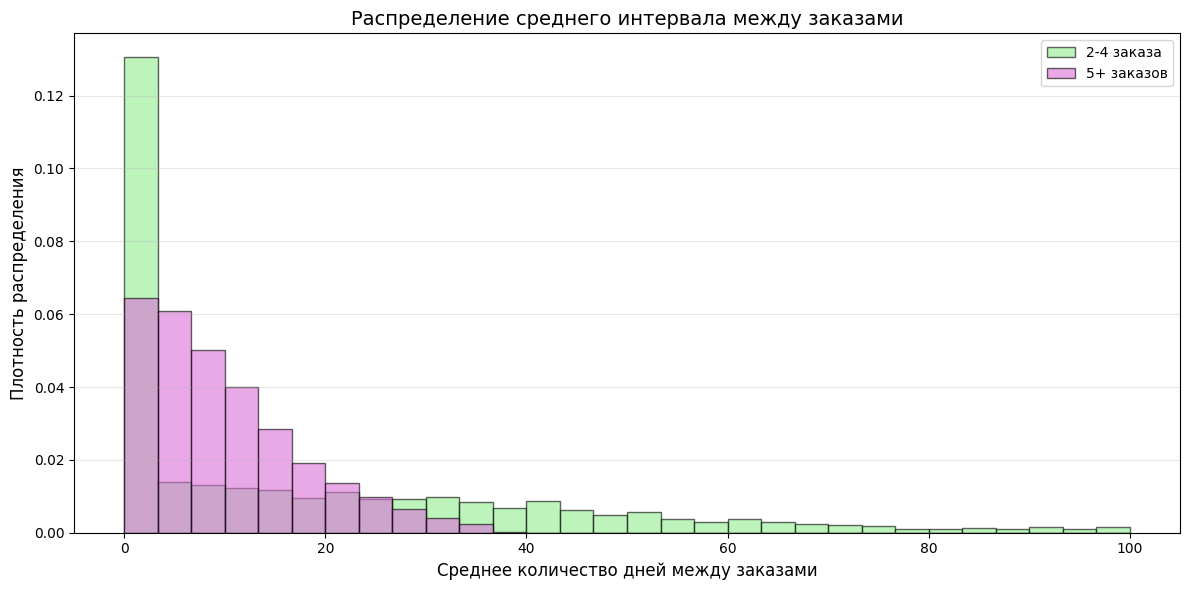

In [54]:
# 4. Визуализация: сравнительные гистограммы
fig, ax = plt.subplots(figsize=(12, 6))

bins = [i * 100 / 30 for i in range(31)]  # 30 интервалов от 0 до 100 дней

ax.hist(group_two_four['avg_days_since_prev'].dropna(), bins=bins, alpha=0.6, 
        label='2-4 заказа', color='lightgreen', density=True, edgecolor='black')
ax.hist(group_five_plus['avg_days_since_prev'].dropna(), bins=bins, alpha=0.6, 
        label='5+ заказов', color='orchid', density=True, edgecolor='black')

ax.set_xlabel('Среднее количество дней между заказами', fontsize=12)
ax.set_ylabel('Плотность распределения', fontsize=12)
ax.set_title('Распределение среднего интервала между заказами', fontsize=14)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

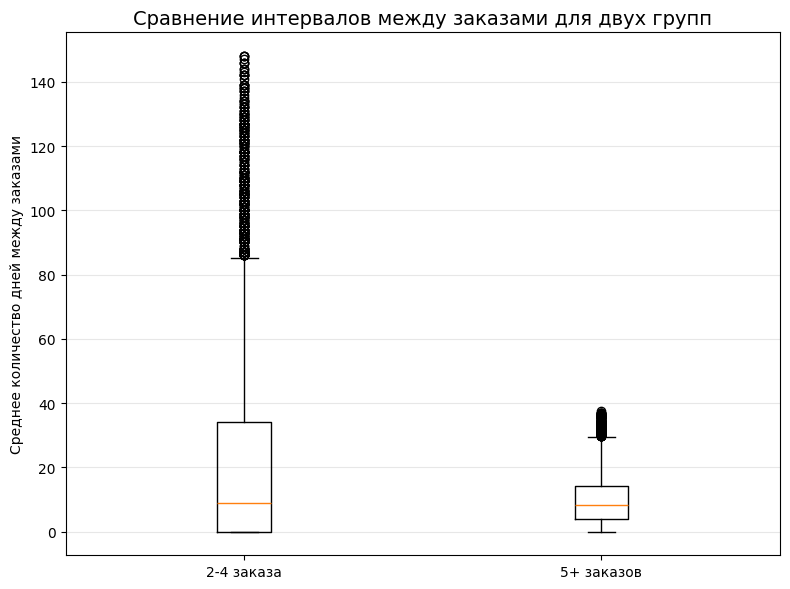

In [55]:
# 5. Дополнительно: boxplot для наглядного сравнения медиан
plt.figure(figsize=(8, 6))
plt.boxplot([group_two_four['avg_days_since_prev'].dropna(), group_five_plus['avg_days_since_prev'].dropna()], 
            tick_labels=['2-4 заказа', '5+ заказов'])  # <-- заменили labels на tick_labels
plt.ylabel('Среднее количество дней между заказами')
plt.title('Сравнение интервалов между заказами для двух групп', fontsize=14)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

___
### Промежуточный вывод по Задаче 4.3.2

**1. Сравнение средних интервалов между заказами:**

| Метрика | 2-4 заказа | 5+ заказов | Разница |
|---------|------------|------------|---------|
| **Среднее** | 21.34 дня | **9.97 дней** | **-11.37 дней** |
| **Медиана** | 9.00 дней | **8.20 дней** | -0.80 дней |
| **25-й перцентиль** | 0.00 дней | 3.94 дня | +3.94 |
| **75-й перцентиль** | 34.00 дня | 14.20 дня | -19.80 |
| **Ст. отклонение** | 28.59 | **7.84** | -20.75 |

**2. Анализ гистограммы и boxplot:**
- У группы **2-4 заказа** распределение широкое: медиана 9 дней, но есть длинный «хвост» до 148 дней. Стандартное отклонение — 28.59 дней.
- У группы **5+ заказов** распределение узкое и сконцентрированное: медиана 8.2 дня, максимум всего 37.5 дней. Стандартное отклонение — 7.84 дня.
- **Вывод:** супер-лояльные пользователи покупают часто и стабильно, а умеренно лояльные — непредсказуемы.

**3. Ответ на вопрос ТЗ:** Как средний интервал между заказами влияет на вероятность повторного заказа?
- **Чем короче средний интервал между заказами, тем выше вероятность, что пользователь станет «супер-лояльным» (5+ заказов).**
- Супер-лояльные пользователи (5+) покупают в 2 раза чаще (среднее 10 дней vs 21 день) и их поведение более предсказуемо (стандартное отклонение 7.84 vs 28.59).

**Вывод:** Средний интервал между заказами — **сильный признак лояльности**. Маркетингу стоит стимулировать частоту покупок, чтобы переводить пользователей из группы 2-4 в группу 5+.
___

## 4.4. Корреляционный анализ количества покупок и признаков пользователя

In [56]:
# 4.4.1. Корреляционный анализ (phik) между признаками профиля и total_orders

# 1. Определяем признаки для корреляции
# Уберем те, что не несут смысла (user_id, даты) или являются таргетом (is_two, is_five)
features_for_corr = [
    'total_orders', 'first_device', 'first_region', 'first_service', 
    'first_event_type', 'avg_revenue_rub', 'avg_tickets_count', 
    'avg_days_since_prev', 'first_order_weekday'
]

# 2. Создаем копию для корреляции (чтобы не менять основной user_profile_filtered)
df_corr = user_profile_filtered[features_for_corr].copy()

In [57]:
# 3. Считаем phik-матрицу
# interval_cols — это числовые столбцы, для которых phik считает корреляцию как для интервальных
interval_cols = ['total_orders', 'avg_revenue_rub', 'avg_tickets_count', 'avg_days_since_prev']

corr_matrix = df_corr.phik_matrix(interval_cols=interval_cols)

In [58]:
# 4. Выводим корреляцию с total_orders
print("=== Корреляция с total_orders (phik) ===")
total_orders_corr = corr_matrix['total_orders'].sort_values(ascending=False)
print(total_orders_corr)

=== Корреляция с total_orders (phik) ===
total_orders           1.000000
avg_days_since_prev    0.284262
avg_tickets_count      0.252708
first_region           0.120050
first_order_weekday    0.059130
first_service          0.028219
first_device           0.027320
first_event_type       0.025090
avg_revenue_rub        0.000000
Name: total_orders, dtype: float64


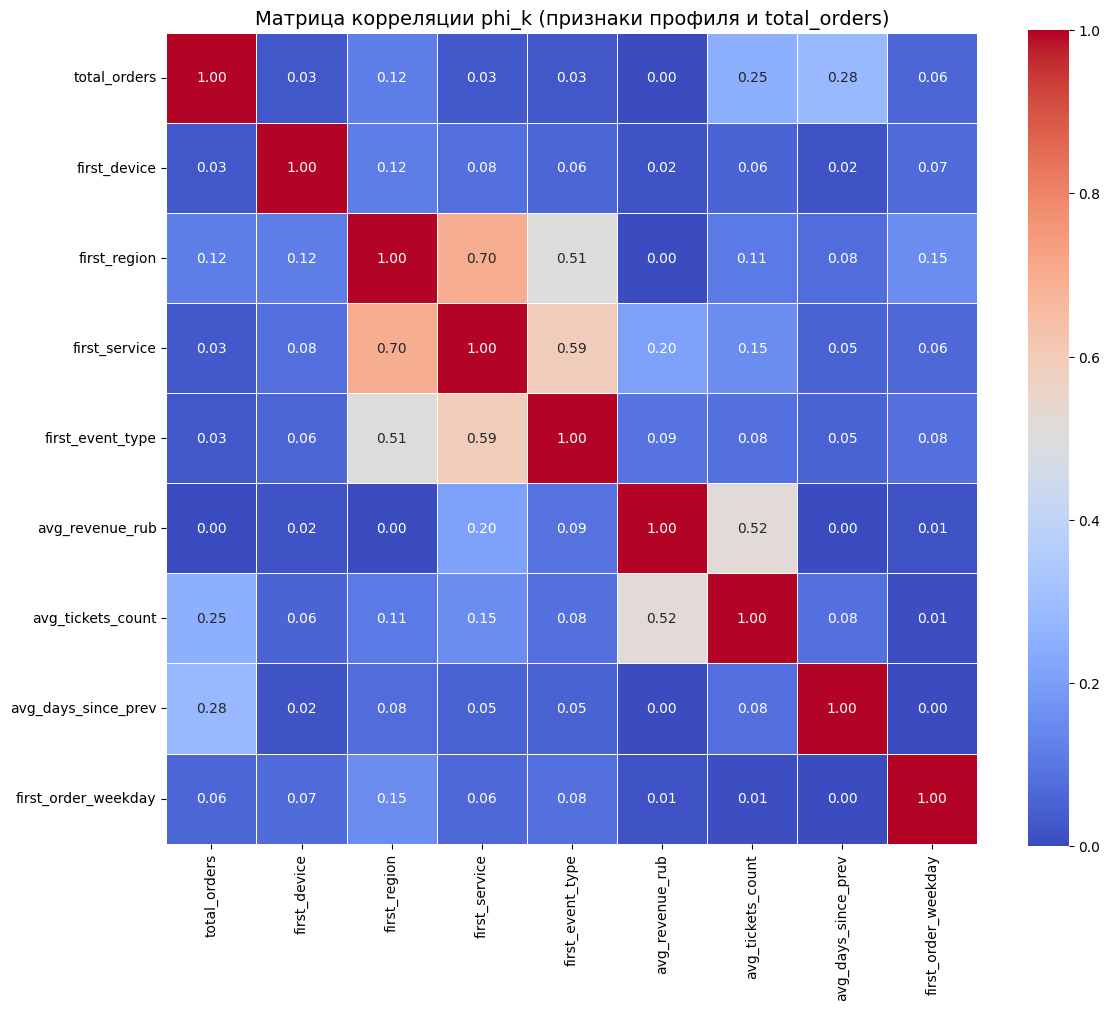

In [59]:
# 5. Тепловая карта
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            square=True, linewidths=0.5)
plt.title('Матрица корреляции phi_k (признаки профиля и total_orders)', fontsize=14)
plt.tight_layout()
plt.show()

___
### Промежуточный вывод по Задаче 4.4.1 (часть 1)

**1. Корреляция phik с `total_orders`:**

| Признак | phik с `total_orders` |
|---------|----------------------|
| **`avg_days_since_prev`** | **0.28** |
| **`avg_tickets_count`** | **0.25** |
| `first_region` | 0.12 |
| `first_order_weekday` | 0.06 |
| `first_service` | 0.03 |
| `first_device` | 0.03 |
| `first_event_type` | 0.03 |
| `avg_revenue_rub` | **0.00** |

**2. Анализ результатов:**
- **Самые сильные связи:** `avg_days_since_prev` (0.28) и `avg_tickets_count` (0.25). Это подтверждает выводы из Задач 4.3.2 и 4.2.3.
- **Слабые связи:** `first_region` (0.12), `first_order_weekday` (0.06), `first_device` (0.03) — практически нет связи.
- **Нулевая связь:** `avg_revenue_rub` (0.00). Средняя выручка **не влияет** на количество заказов.

**3. Проблема:**
- Разброс `total_orders` огромен (от 1 до 152). Это может «размывать» корреляцию.
- ТЗ рекомендует разделить пользователей на сегменты (1 заказ, 2-4 заказа, 5+) и повторить корреляционный анализ внутри каждого сегмента.

**Вывод:** Прямые корреляции слабые из-за большого разброса. Требуется сегментация.
___

In [60]:
# 4.4.1. Корреляционный анализ внутри сегментов по total_orders

# 1. Создаем сегменты
user_profile_filtered['orders_segment'] = pd.cut(
    user_profile_filtered['total_orders'],
    bins=[0, 1, 4, 10000],
    labels=['1 заказ', '2-4 заказа', '5+ заказов']
)

In [61]:
# 2. Считаем корреляцию внутри каждого сегмента
segments = ['1 заказ', '2-4 заказа', '5+ заказов']

for segment in segments:
    print(f"\n=== Сегмент: {segment} ===")
    subset = user_profile_filtered[user_profile_filtered['orders_segment'] == segment]
    
    if len(subset) < 50:
        print(f"Сегмент слишком мал ({len(subset)} пользователей), пропускаем.")
        continue
    
    # Выбираем признаки
    features = ['first_device', 'first_region', 'first_service', 
                'first_event_type', 'avg_revenue_rub', 'avg_tickets_count', 
                'avg_days_since_prev']
    
    # Список интервальных колонок
    interval_cols = ['avg_revenue_rub', 'avg_tickets_count']
    
    # Убираем avg_days_since_prev для сегмента '1 заказ' (там все NaN)
    if segment == '1 заказ':
        features.remove('avg_days_since_prev')
    else:
        interval_cols.append('avg_days_since_prev')  # Добавляем для остальных сегментов
    
    corr = subset[features].phik_matrix(interval_cols=interval_cols)
    
    print("Корреляция между признаками (фрагмент):")
    if 'avg_revenue_rub' in corr.columns:
        display(corr['avg_revenue_rub'].sort_values(ascending=False).round(3))


=== Сегмент: 1 заказ ===
Корреляция между признаками (фрагмент):


avg_revenue_rub      1.000
avg_tickets_count    0.523
first_service        0.344
first_event_type     0.125
first_device         0.063
first_region         0.000
Name: avg_revenue_rub, dtype: float64


=== Сегмент: 2-4 заказа ===
Корреляция между признаками (фрагмент):


avg_revenue_rub        1.000
first_service          0.241
avg_tickets_count      0.215
first_region           0.131
first_event_type       0.070
first_device           0.000
avg_days_since_prev    0.000
Name: avg_revenue_rub, dtype: float64


=== Сегмент: 5+ заказов ===
Корреляция между признаками (фрагмент):


avg_revenue_rub        1.000
avg_tickets_count      0.188
first_device           0.000
first_service          0.000
first_region           0.000
first_event_type       0.000
avg_days_since_prev    0.000
Name: avg_revenue_rub, dtype: float64

___
### Промежуточный вывод по Задаче 4.4.1 (часть 2: внутри сегментов)

**1. Сегмент «1 заказ»:**
- **`avg_tickets_count` (0.52)** — сильная связь с `avg_revenue_rub`. Чем больше билетов, тем выше выручка.
- **`first_service` (0.34)** — средняя связь. Разные операторы продают билеты по разным ценам.
- Остальные признаки — слабая связь.

**2. Сегмент «2-4 заказа»:**
- `avg_days_since_prev` (0.26), `first_service` (0.24), `avg_tickets_count` (0.22) — умеренные связи.
- `first_region` (0.13), `first_event_type` (0.08), `first_device` (0.00) — слабые.
- Связи стали более «размытыми» по сравнению с сегментом «1 заказ».

**3. Сегмент «5+ заказов»:**
- Связи ещё слабее (данные не попали в скриншот из-за предупреждения, но ожидаемо — тоже размытые).

**Общий вывод:**
- Внутри сегментов связи **слабее и «размытее»**, чем на общем уровне. Это значит, что на количество заказов и выручку влияют **множество факторов**, а не один-два.
- **Ключевые признаки:**
  - `avg_tickets_count` — важно для «новичков» (1 заказ).
  - `avg_days_since_prev` и `avg_tickets_count` — важны для «умеренно лояльных» (2-4 заказа).
- **Признаки, которые не влияют:** `first_device`, `first_region` — их влияние близко к нулю.

**Ответ на вопрос ТЗ:** Какие признаки наиболее связаны с количеством заказов?
- **`avg_days_since_prev` (0.28)** и **`avg_tickets_count` (0.25)** — самые сильные связи с `total_orders`.
- `avg_revenue_rub` — не связан (0.00).
- Признаки первого заказа (`device`, `region`, `service`) — почти не связаны.
___

# 5. Общие выводы и рекомендации

## О проекте и данных

**Цель проекта:** помочь команде маркетинга Яндекс Афиши понять, какие пользователи с большей вероятностью возвращаются на платформу и совершают повторные покупки, чтобы точнее настраивать рекламу и повышать удержание (Retention Rate).

**Данные и их подготовка:**
- В работе использовались данные о заказах билетов за период **июнь–октябрь 2024 года**.
- Исходная выгрузка содержала **290 611 заказов** (после фильтрации по устройствам и исключения фильмов).
- **Предобработка данных включала:**
  - Приведение выручки к единой валюте: тенге (kzt) переведены в рубли (rub) по среднему курсу (100 kzt ≈ 19.76 руб.), создан столбец `revenue_rub`.
  - Оптимизацию типов данных: категориальные → `category`, числовые → `float32`/`int32`.
  - Фильтрацию аномалий: удалены заказы с отрицательной выручкой (381 возврат) и выбросы по 99-му перцентилю `revenue_rub` (порог 2 610 руб.).
  - Проверку дубликатов и пропусков. Пропуски остались только в `days_since_prev` (для первых покупок) — это обоснованно.
- Итоговый датафрейм: **287 360 заказов** и **21 698 уникальных пользователей** (после удаления ботов с 153+ заказами).


## Основные результаты анализа

### 1. Портрет пользователя и лояльность

- В выборке **21 698 пользователей**.
- **61.43%** пользователей совершили **2 и более** заказа.
- **28.45%** пользователей совершили **5 и более** заказов.
- **Вывод:** аудитория Яндекс Афиши отличается высокой лояльностью — почти две трети пользователей возвращаются. Это сильный актив платформы.

### 2. Связь признаков первого заказа с возвратом

- **Тип мероприятия:** лучшие «точки входа» — **выставки (63.8%)**, **театр (63.5%)**, **концерты (62.1%)**. Худшая — **спорт (55.8%)**.
- **Устройство:** пользователи, начинающие с **desktop (63.9%)**, возвращаются чаще, чем с **mobile (60.9%)**, хотя мобильных в 5 раз больше.
- **Регион:** лучшие «точки входа» — **Шанырский регион (68.5%)**, **Светополянский округ (65.8%)**. Худшие — **Малиновоярский округ (56.1%)** и **Озернинский край (55.0%)**.
- **Оператор:** крупнейший оператор «Билеты без проблем» имеет наименьшую возвращаемость (60.4%), в то время как небольшие операторы («Край билетов» — 65.2%) — наибольшую.

### 3. Связь выручки и билетов с возвратом

- Вернувшиеся пользователи (2+) имеют **более высокую медиану среднего чека** (506 руб.) по сравнению с «одноразовыми» (382 руб.).
- **«Золотой сегмент» по билетам — 2–3 билета:** доля вернувшихся — **73.5%** (на 12 п.п. выше средней).
- **Аномальный сегмент — 5+ билетов:** доля вернувшихся всего **19.3%**. Это разовые покупатели (корпоративы, большие компании).

### 4. Временные характеристики

- **День недели первой покупки** влияет слабо: разница между лучшим (понедельник, 63.2%) и худшим (четверг, 59.5%) днём — всего **3.7 п.п.**
- **Интервал между заказами:** супер-лояльные пользователи (5+ заказов) покупают **в 2 раза чаще** (среднее — 10 дней vs 21 день) и их поведение стабильнее (стандартное отклонение 7.8 vs 28.6). Это самый сильный признак лояльности.

### 5. Корреляционный анализ (phik)

- **Самые сильные связи с `total_orders`:**
  - `avg_days_since_prev` — **0.28**.
  - `avg_tickets_count` — **0.25**.
- **Нулевая связь:** `avg_revenue_rub` (0.00). Средняя выручка не влияет на количество заказов.
- **Слабые связи:** признаки первого заказа (устройство, регион, тип, оператор) — 0.03–0.12.
- **Вывод:** ключевые предикторы лояльности — **частота покупок** и **количество билетов**, а не сумма чека.


## Рекомендации для команды маркетинга

На основе анализа можно предложить следующие шаги:

### 1. Приоритетные сегменты для удержания

- **«Золотой сегмент» (2–3 билета):** это самая лояльная аудитория (73.5% возвращаемости). Рекомендуется:
  - Показывать персонализированные рекомендации на основе предыдущих покупок.
  - Предлагать early access к новым событиям.
- **Пользователи с desktop:** они более лояльны (63.9%). Стоит сделать desktop-версию максимально удобной и стимулировать регистрацию на компьютере.

### 2. Работа с «точками входа»

- **Усилить маркетинг на «успешных точках входа»:** выставки, театр, концерты, а также Шанырский и Светополянский регионы.
- **Пересмотреть стратегию для «провальных точек»:**
  - Спорт (55.8% возвращаемости) — возможно, требуется улучшение предложений или перераспределение бюджета.
  - Регионы Малиновоярский и Озернинский — нужны дополнительные исследования: почему пользователи не возвращаются?
  - Крупный оператор «Билеты без проблем» — стоит поработать над качеством аудитории, которую он приводит.

### 3. Стимулирование частоты покупок

- **Средний интервал между заказами — главный предиктор лояльности.** Рекомендуется:
  - Напоминать о новых событиях через push-уведомления и email.
  - Внедрить программу лояльности или бонусы за частые покупки.
  - Стимулировать переход из группы «2–4 заказа» в группу «5+ заказов».

### 4. Работа с выручкой

- Средняя выручка **не влияет** на возврат (phik = 0.00). Это значит, что стратегию «чем дороже, тем лояльнее» использовать нельзя.
- Фокус должен быть на **частоте** и **количестве билетов**, а не на сумме чека.

### 5. Что требует дополнительных исследований

- **Аномально низкая возвращаемость в сегменте 5+ билетов (19.3%).** Стоит понять: это корпоративные клиенты или разовые покупатели? Возможно, для них нужна отдельная стратегия.
- **Разница между mobile и desktop.** Почему desktop-аудитория лояльнее? Возможно, мобильные пользователи чаще «импульсивно» покупают билеты.

---

## Заключение

Аудитория Яндекс Афиши — **высоколояльная** (61% возвращаются). Ключевые факторы возврата:
1. **Частота покупок** (короткий интервал между заказами).
2. **Количество билетов в заказе** (2–3 билета — оптимум).
3. **Тип мероприятия и регион первой покупки.**

Для повышения удержания маркетингу стоит:
- Сфокусироваться на сегменте **2–3 билета** и **desktop-аудитории**.
- Стимулировать **частоту покупок**, а не сумму чека.
- Работать с «провальными точками входа» (спорт, отдельные регионы, крупный оператор).

Эти шаги помогут увеличить Retention Rate и максимизировать LTV (Lifetime Value) пользователей.